# ISMIR 2021 Piano Transcription — Faithful PyTorch Replication

PyTorch reimplementation of Hawthorne et al. *"Sequence-to-Sequence Piano Transcription with Transformers"* (ISMIR 2021).
The architecture and preprocessing are copied from the paper and from the original JAX implementation in `google-research/mt3` (specifically the `ismir2021.gin` configuration).

## What this does

1. Downloads a small subset of MAESTRO V3.0.0 (20 train / 3 val / 3 test pieces)
2. Preprocesses audio → log-mel spectrograms (512 mel bins, 16 kHz, FFT=2048, hop=128) and MIDI → MIDI-like event tokens with **absolute time shifts**
3. Defines a T5.1.1-small encoder-decoder Transformer (54M params, GEGLU, fixed sinusoidal positional embeddings)
4. Trains for a few thousand steps on one GPU
5. Runs greedy autoregressive inference on a held-out piece
6. Evaluates onset / onset+offset / onset+offset+velocity F1 via `mir_eval`
7. Visualises predicted vs ground-truth piano rolls

## Intentional deviations from the paper (for practical reasons)

- **Training budget**: ~2K steps at effective batch 32, not 400K at batch 256. Expect onset F1 well below the paper's 96%.
- **Data**: 20 train pieces, not ~960.
- **MIDI parsing**: `pretty_midi` instead of `note_seq` (note_seq's `midi_io` wraps `pretty_midi` internally, but `pretty_midi` installs cleaner on Colab).
- **Mel spectrogram**: `torchaudio.transforms.MelSpectrogram` (HTK scale) instead of `tf.signal`. Very minor filterbank differences.

Everything else — vocabulary layout, absolute-time RLE semantics, T5 architecture details, Adafactor optimizer, loss — matches the original paper / `mt3` repo.

## Expected runtime on a Colab T4

| Step | Time |
|---|---|
| Install deps | 30 s |
| Download MAESTRO subset (~4 GB) | 2–5 min |
| Preprocess pieces (full-song log-mel) | 5–10 min |
| Train 2 000 steps | 60–90 min |
| Inference + eval on 3 val pieces (first 30 s each) | 5–10 min |


## 1. Install dependencies

`torch` and `torchaudio` come preinstalled on Colab. We add:

- **pretty_midi** — MIDI file I/O
- **mir_eval** — note-based transcription F1 metrics
- **transformers** — for `Adafactor` (the paper's optimizer)
- **tqdm**, **matplotlib** — progress and plots


In [1]:
!pip install -q pretty_midi mir_eval "transformers>=4.30" tqdm matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 73.6 MB/s eta 0:00:00:00:010:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.6 MB/s eta 0:00:00


In [2]:
import os, sys, json, math, random, time, gzip, pickle, urllib.request
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader

import pretty_midi
import mir_eval
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from transformers.optimization import Adafactor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}  ({props.total_memory/1e9:.1f} GB)")
print(f"PyTorch: {torch.__version__}   Torchaudio: {torchaudio.__version__}")

# Reproducibility (not bit-exact because cuDNN/cuBLAS nondeterminism is allowed for speed).
# these CUDA libraries optimize for speed in exchange for true determinism
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)


Device: cuda
GPU: Tesla T4  (15.6 GB)
PyTorch: 2.10.0+cu128   Torchaudio: 2.10.0+cu128


## 2. Persistent storage

On Colab we mount Google Drive so that downloaded audio, preprocessed tensors, and training checkpoints survive across sessions. On a non-Colab machine we just use a local directory.

Everything downstream references `DATA_DIR`, `CACHE_DIR`, `CKPT_DIR`. Change the root if you want to point the notebook at a different location (e.g. Oscar scratch).


In [3]:
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/piano_transcription")
else:
    DRIVE_ROOT = Path("./piano_transcription_cache")

DATA_DIR  = DRIVE_ROOT / "maestro_subset"     # raw wav + midi
CACHE_DIR = DRIVE_ROOT / "cache"              # preprocessed mel + notes
CKPT_DIR  = DRIVE_ROOT / "checkpoints"        # training checkpoints
for d in (DATA_DIR, CACHE_DIR, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Data:  {DATA_DIR}")
print(f"Cache: {CACHE_DIR}")
print(f"Ckpt:  {CKPT_DIR}")


Mounted at /content/drive
Data:  /content/drive/MyDrive/piano_transcription/maestro_subset
Cache: /content/drive/MyDrive/piano_transcription/cache
Ckpt:  /content/drive/MyDrive/piano_transcription/checkpoints


## 3. Configuration

All hyperparameters live in one `Config` dataclass. The values are copied verbatim from the paper (Table 3) and the original gin files [`mt3/gin/model.gin`](https://github.com/magenta/mt3/blob/main/mt3/gin/model.gin), [`mt3/gin/ismir2021.gin`](https://github.com/magenta/mt3/blob/main/mt3/gin/ismir2021.gin), and [`mt3/gin/train.gin`](https://github.com/magenta/mt3/blob/main/mt3/gin/train.gin). Comments reference the specific source.


In [4]:
@dataclass
class Config:
    """Hyperparameters that define the audio representation, token vocabulary, model, and training loop."""

    # --- Audio -> log-mel spectrogram (paper section 4; mt3/spectrograms.py) ---
    # The model reads a "spectrogram" rather than raw samples. To build it, we slide a window
    # across the audio and run FFT at each position to produce one column of frequencies.

    # Sound in a .wav is stored as a long list of numbers (samples). sample_rate is how many
    # of those numbers represent one second of audio. Higher = finer time detail, more data.
    # Incoming waveform audio is resampled to this many samples per second.
    sample_rate: int = 16000

    # Number of raw audio samples between adjacent spectrogram frames (i.e.
    # how many samples we slide between positions when running the FFT sliding window). With
    # sample_rate=16000, 128 samples is 0.008 s, so the model sees a new frame
    # every 8 ms. Smaller hops give finer timing but more frames to process.
    hop_width: int = 128

    # Size of the short audio window analyzed by each Fourier transform. At
    # 16 kHz, 2048 samples cover 0.128 s of sound. Windows overlap heavily because
    # fft_size is much larger than hop_width.
    fft_size: int = 2048

    # Number of frequency features kept per spectrogram frame after converting
    # raw Fourier frequencies to the mel scale, a frequency scale spaced more like
    # human pitch perception. This is the input feature width before projection
    # into the Transformer's d_model dimension.
    num_mel_bins: int = 512

    # Lowest frequency, in hertz, included in the mel filterbank. 20 Hz is near
    # the lower edge of human hearing; torchaudio's default upper edge is the
    # 'Nyquist frequency', sample_rate / 2 = 8000 Hz here.
    mel_lo_hz: float = 20.0

    # --- Event vocabulary (paper section 3.2; mt3/vocabularies.py) ---
    # Time resolution used when turning note times (real) into representative tokens for time. 
    # 100 steps per second means one shift step is 0.01 s = 10 ms. During tokenization, 
    # each note time relative to the segment start is rounded to this grid.
    steps_per_second: int = 100

    # TODO cont here
    # Largest amount of time a single shift token can represent, in seconds.
    # max_shift_steps below converts this to the vocabulary value range 0..1000.
    # Longer times can be represented by emitting multiple shift tokens whose
    # values sum to the desired absolute time step.
    max_shift_seconds: int = 10

    # Number of nonzero MIDI velocity bins used for note-on events. MIDI velocity
    # is the key-strike intensity range 1..127. The codec also includes velocity
    # value 0 as a special note-off marker, so the velocity event range is 0..127.
    num_velocity_bins: int = 127

    # Inclusive MIDI pitch range represented in the vocabulary. MIDI pitch numbers
    # name keys by semitone; middle C is 60. The full 0..127 range is kept even
    # though acoustic piano notes are normally 21..108.
    min_pitch: int = 0
    max_pitch: int = 127

    # --- Sequence lengths (paper; ismir2021.gin TASK_FEATURE_LENGTHS) ---
    # Number of spectrogram frames supplied to the encoder for one training
    # example. Combined with hop_width and sample_rate, this corresponds to
    # 512 * 128 / 16000 = 4.096 s of audio. The mel transform returns 513 frames
    # for this many samples because center=True pads the waveform; the dataset
    # truncates/pads to exactly this length.
    input_length: int = 512

    # Fixed length of the decoder target sequence in model-token IDs. Each target
    # contains encoded note/time/velocity events, then EOS, then PAD tokens. If a
    # segment produces more than target_length - 1 events, it is truncated before
    # appending EOS.
    target_length: int = 1024

    # --- Transformer (T5.1.1-small; paper Table 3 / mt3/gin/model.gin) ---
    # Width of every hidden vector inside the Transformer. The 512 mel features in
    # each frame are first projected to this size, token embeddings use this size,
    # and all encoder/decoder layer inputs and outputs have this width.
    d_model: int = 512

    # Hidden width of the feed-forward block inside each Transformer layer. This
    # notebook uses T5's GEGLU feed-forward variant: it expands from d_model to
    # d_ff, applies a gated nonlinearity, then projects back to d_model.
    d_ff: int = 1024

    # Number of attention heads in each self-attention and cross-attention module.
    # Heads let the model compute several attention patterns in parallel.
    num_heads: int = 6

    # Per-head query/key/value width. The attention inner width is
    # num_heads * d_kv = 384, which intentionally differs from d_model=512 in the
    # T5-small configuration; the attention output projection maps it back to 512.
    d_kv: int = 64

    # Number of repeated encoder layers that process the input spectrogram frames.
    num_encoder_layers: int = 8

    # Number of repeated decoder layers that autoregressively predict event tokens
    # while attending to the encoder output.
    num_decoder_layers: int = 8

    # Probability of dropping activations during training in embeddings,
    # attention, and feed-forward blocks. This regularizes the model; dropout is
    # disabled automatically by model.eval() during evaluation/inference.
    dropout: float = 0.1

    # --- Loss (mt3/gin/model.gin) ---
    # Weight on the T5 z-loss term, which mildly penalizes very large logits
    # before the softmax. It helps keep the token distribution numerically stable
    # without changing the target labels.
    z_loss: float = 1e-4

    # Amount of label smoothing passed to cross entropy. 0.0 means the target
    # token is treated as fully correct and all other tokens as incorrect; larger
    # values would distribute a little target probability to other tokens.
    label_smoothing: float = 0.0

    # --- Optimizer and schedule (mt3/gin/train.gin) ---
    # Peak and post-warmup learning rate for Adafactor. The schedule ramps up from
    # near zero during warmup_steps, then stays at this value.
    learning_rate: float = 3e-4

    # Number of optimizer steps used for the linear warmup. Step 0 uses a small
    # fraction of learning_rate; after this many steps, the schedule is constant.
    warmup_steps: int = 1000

    # --- Training budget (scaled for Colab) ---
    # Number of segments processed simultaneously in one forward/backward pass.
    # Larger batches use more GPU memory and usually make gradients less noisy.
    batch_size: int = 32

    # Number of mini-batches whose gradients are accumulated before one optimizer
    # update. The effective batch size is batch_size * grad_accum.
    grad_accum: int = 1

    # Total number of optimizer updates to run before stopping training.
    total_steps: int = 11000

    # Print loss/accuracy and update the progress display every this many
    # optimizer steps.
    log_every: int = 50

    # Save the experiment-specific latest checkpoint every this many optimizer steps,
    # and also at the final step, so training can resume after an interruption.
    ckpt_every: int = 100

    # Synthetic length returned by the training Dataset. Training examples are
    # sampled randomly from cached pieces, so this only controls how many random
    # examples a DataLoader epoch contains; the outer loop still stops at
    # total_steps.
    steps_per_epoch: int = 4000

    # --- Dataset selection ---
    # Which dataset supplies the train and validation pieces. Either 'maestro' or 'maps'.
    train_valid_dataset: str = "maestro"

    # Which dataset supplies the test pieces. Either 'maestro' or 'maps'.
    test_dataset: str = "maps"

    # Apply the [min_duration_sec, max_duration_sec] duration filter to MAESTRO pieces.
    # MAPS metadata has no duration field (see maps_range_probe.py) so duration filtering
    # is always skipped for MAPS regardless of this flag.
    filter_duration: bool = True

    # --- Dataset subset ---
    # Number of metadata rows to keep from each split after (optional) duration filtering.
    # These limits reduce download, preprocessing, and training time.
    num_train_pieces: int = 100
    num_val_pieces: int = 15
    num_test_pieces: int = 15

    # Keep only pieces whose full recording duration is in this inclusive range.
    # Very short pieces provide little variety; very long pieces cost more to
    # download/preprocess and can dominate the subset size.
    # (Only applied to MAESTRO, and only when filter_duration is True.)
    min_duration_sec: float = 120.0
    max_duration_sec: float = 360.0

    # --- Automatic mixed precision ---
    # If True on CUDA, run forward/loss computation in fp16 autocast with a
    # GradScaler to save memory and improve speed. False keeps fp32 training,
    # which is closer to the paper and avoids fp16-specific numerical behavior.
    use_amp: bool = False

    # --- Experiment flags ---
    # Which spectrogram representation to feed the encoder
    # 'log_mel': 512-bin log-mel (baseline). 'stft': log-magnitude STFT (fft_size//2+1 = 1025 bins).
    input_type: str = "log_mel"  # "log_mel" | "stft"
    
    # 'Whether the MIDI-like event vocabluary represents time as absolute offset
    # from start of the segment (default/original), or relative time shifts from 
    # previous event (earlier work like T5)
    time_offset_type: str = "relative" # "relative" | "absolute" ..
    

    @property
    def input_dim(self) -> int:
        """Feature width fed to input_proj: 512 for log-mel, 1025 for STFT."""
        return self.num_mel_bins if self.input_type == "log_mel" else self.fft_size // 2 + 1

    @property
    def checkpoint_prefix(self) -> str:
        """Experiment-specific checkpoint stem, used to avoid overwriting incompatible runs."""
        return f"{self.input_type}_{self.time_offset_type}_h{self.num_heads}"

    @property
    def segment_samples(self) -> int:
        # Number of raw waveform samples needed for one encoder input segment:
        # input_length frames * hop_width samples/frame = 65,536 samples = 4.096 s.
        return self.input_length * self.hop_width

    @property
    def num_pitches(self) -> int:
        # Count of integer MIDI pitch values in the inclusive vocabulary range.
        return self.max_pitch - self.min_pitch + 1

    @property
    def max_shift_steps(self) -> int:
        # Largest shift token value measured in 10 ms steps: 100 steps/s * 10 s.
        return self.steps_per_second * self.max_shift_seconds


config = Config()
print(f"Segment length: {config.segment_samples/config.sample_rate:.3f} s"
      f"  ({config.segment_samples} samples, {config.input_length} mel frames)")
print(f"Effective batch: {config.batch_size * config.grad_accum}"
      f"  ({config.batch_size} × grad_accum {config.grad_accum})")


Segment length: 4.096 s  (65536 samples, 512 mel frames)
Effective batch: 32  (32 × grad_accum 1)


In [ ]:
# RESET FOR NEW TRAINING -- only run after PianoTranscriptionTransformer and other downstream classes and objects are defined (i.e. after training)
# In a new cell, before re-running training (we should save models we want to keep before this).
import shutil
if CKPT_DIR.exists(): # delete old checkpoints
    shutil.rmtree(CKPT_DIR); CKPT_DIR.mkdir(parents=True)

# Rebuild config, model, optimizer (fresh training objects).
config = Config()
model = PianoTranscriptionTransformer(config, vocab_size=VOCAB_SIZE_PADDED).to(device)
optimizer = Adafactor(model.parameters(), lr=config.learning_rate,
                      scale_parameter=False, relative_step=False, warmup_init=False,
                      beta1=None, weight_decay=0.0, clip_threshold=1.0)
print(f"Fresh model, fp32, LR={config.learning_rate}, effective batch={config.batch_size*config.grad_accum}")


NameError: name 'PianoTranscriptionTransformer' is not defined

In [6]:
# Shared HTTP Range reader used by both MAESTRO and MAPS remote zip access.
class HttpRangeReader:
    """Seekable file-like object backed by HTTP Range requests."""

    def __init__(self, url: str):
        self.url = url
        head = urllib.request.urlopen(urllib.request.Request(url, method="HEAD"))
        self._size = int(head.headers["Content-Length"])
        self._pos = 0

    def seekable(self) -> bool:
        return True

    def seek(self, pos: int, whence: int = 0) -> int:
        if whence == 0:
            self._pos = pos
        elif whence == 1:
            self._pos += pos
        elif whence == 2:
            self._pos = self._size + pos
        return self._pos

    def tell(self) -> int:
        return self._pos

    def read(self, n: int = -1) -> bytes:
        if n == -1 or self._pos + n > self._size:
            n = self._size - self._pos
        if n <= 0:
            return b""

        req = urllib.request.Request(
            self.url,
            headers={"Range": f"bytes={self._pos}-{self._pos + n - 1}"},
        )
        data = urllib.request.urlopen(req).read()
        self._pos += len(data)
        return data


## 4. Data subset selection

Pick a small subset of pieces from either MAESTRO and/or MAPS depending on
`config.train_valid_dataset` and `config.test_dataset`.

For MAESTRO, this downloads the v3.0.0 metadata JSON (tiny, ~1 MB) and uses it directly.
For MAPS (Zenodo record `18160555`), this builds an equivalently formatted column-oriented
metadata JSON locally by inspecting each per-piano archive over HTTP Range requests. MAPS metadata
deliberately omits `duration`, so duration filtering is skipped for MAPS regardless of the flag filter_duration.

The split convention used for MAPS (chosen for AMT stress-testing): synthesized pianos
form `train`, `ENSTDkCl` is `validation`, `ENSTDkAm` is `test`.

Either metadata JSON, once loaded, is column-oriented (each top-level key is a field
name; the value is a `{str_index: value}` dict). The same transpose
(`[{k: raw[k][str(i)] for k in raw} for i in range(n_rows)]`) turns it into a list of
row dicts.

- Up to `config.num_train_pieces / num_val_pieces / num_test_pieces` per split
- For MAESTRO: optional 2–6 minute duration filter (controlled by `config.filter_duration`)
- Random with a fixed seed so the selection is reproducible


In [7]:
import posixpath, re, zipfile
from dataclasses import asdict
from typing import Iterable

MAPS_ZENODO_RECORD_URL = "https://zenodo.org/api/records/18160555"

# These are the record's individual content files. They support HTTP 206 Range
# requests and can be opened with zipfile.ZipFile(HttpRangeReader(url)).
MAPS_ARCHIVES: dict[str, str] = {
    "AkPnBcht.zip": "https://zenodo.org/api/records/18160555/files/AkPnBcht.zip/content",
    "AkPnBsdf.zip": "https://zenodo.org/api/records/18160555/files/AkPnBsdf.zip/content",
    "AkPnCGdD.zip": "https://zenodo.org/api/records/18160555/files/AkPnCGdD.zip/content",
    "AkPnStgb.zip": "https://zenodo.org/api/records/18160555/files/AkPnStgb.zip/content",
    "ENSTDkAm.zip": "https://zenodo.org/api/records/18160555/files/ENSTDkAm.zip/content",
    "ENSTDkCl.zip": "https://zenodo.org/api/records/18160555/files/ENSTDkCl.zip/content",
    "SptkBGAm.zip": "https://zenodo.org/api/records/18160555/files/SptkBGAm.zip/content",
    "SptkBGCl.zip": "https://zenodo.org/api/records/18160555/files/SptkBGCl.zip/content",
    "StbgTGd2.zip": "https://zenodo.org/api/records/18160555/files/StbgTGd2.zip/content",
}


@dataclass(frozen=True)
class MapsPiece:
    split: str
    audio_filename: str
    midi_filename: str
    canonical_composer: str
    canonical_title: str
    source_dataset: str
    maps_config: str
    maps_category: str
    archive_key: str
    archive_url: str


# HttpRangeReader is defined once in the shared helper cell immediately above.

def open_remote_zip(archive_url: str) -> zipfile.ZipFile:
    return zipfile.ZipFile(HttpRangeReader(archive_url))

datasets_needed = {config.train_valid_dataset, config.test_dataset}
by_split_per_dataset: Dict[str, Dict[str, list]] = {} # stores dataset name -> {train: .., validation: .., test: ...} obj

if "maestro" in datasets_needed:
    # ----- OLD MAESTRO metadata flow (kept verbatim, now under conditional) -----
    META_URL = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0.json"
    META_PATH = DATA_DIR / "maestro-v3.0.0.json"

    if not META_PATH.exists():
        print(f"Fetching metadata → {META_PATH}")
        urllib.request.urlretrieve(META_URL, META_PATH)
    else:
        print(f"Metadata cached at {META_PATH}")

    with open(META_PATH) as f:
        raw = json.load(f)

    # Transpose column-oriented dict → list of row dicts.
    n_rows = len(raw["split"])
    pieces = [{k: raw[k][str(i)] for k in raw} for i in range(n_rows)]

    print(f"Total MAESTRO pieces: {len(pieces)}")
    print("Splits:", {s: sum(1 for p in pieces if p["split"] == s) for s in {"train","validation","test"}})


    def in_duration_range(p):
        return config.min_duration_sec <= p["duration"] <= config.max_duration_sec


    # CHANGED: duration filter is now MAESTRO-only and gated on config.filter_duration.
    by_split_maestro = {"train": [], "validation": [], "test": []} 
    for p in pieces:
        if p["split"] not in by_split_maestro:
            continue
        if config.filter_duration and not in_duration_range(p):
            continue
        by_split_maestro[p["split"]].append(p)
    by_split_per_dataset["maestro"] = by_split_maestro

if "maps" in datasets_needed:
    def split_for_maps_config(config: str) -> str:
        # Convention for AMT stress-testing: train on synthesized pianos, validate
        # on one real Disklavier subset, and test on the other.
        if config == "ENSTDkAm":
            return "test"
        if config == "ENSTDkCl":
            return "validation"
        return "train"


    def infer_maps_fields(path: str) -> tuple[str, str, str]:
        stem = posixpath.splitext(posixpath.basename(path))[0]
        category = stem.split("-")[0] if "-" in stem else "MAPS"
        match = re.search(r"_([A-Za-z0-9]+)$", stem)
        config = match.group(1) if match else ""
        return category, config, stem


    def build_metadata_for_archive(archive_key: str, archive_url: str) -> list[MapsPiece]:
        zf = open_remote_zip(archive_url)
        names = zf.namelist()
        wavs = {
            posixpath.splitext(posixpath.basename(name))[0]: name
            for name in names
            if name.lower().endswith(".wav") and "/MAPS_MUS-" in f"/{name}"
        }
        midis = {
            posixpath.splitext(posixpath.basename(name))[0]: name
            for name in names
            if name.lower().endswith((".mid", ".midi")) and "/MAPS_MUS-" in f"/{name}"
        }

        pieces: list[MapsPiece] = []
        for stem in sorted(set(wavs) & set(midis)):
            audio_filename = wavs[stem]
            midi_filename = midis[stem]
            category, config, title = infer_maps_fields(audio_filename)
            pieces.append(
                MapsPiece(
                    split=split_for_maps_config(config),
                    audio_filename=audio_filename,
                    midi_filename=midi_filename,
                    canonical_composer="MAPS",
                    canonical_title=title,
                    source_dataset="MAPS",
                    maps_config=config,
                    maps_category=category,
                    archive_key=archive_key,
                    archive_url=archive_url,
                )
            )
        return pieces


    def build_maps_metadata() -> list[MapsPiece]:
        pieces: list[MapsPiece] = []
        for archive_key, archive_url in MAPS_ARCHIVES.items():
            archive_pieces = build_metadata_for_archive(archive_key, archive_url)
            print(f"{archive_key}: {len(archive_pieces)} MAPS_MUS pairs")
            pieces.extend(archive_pieces)
        return pieces


    def to_column_oriented_json(pieces: Iterable[MapsPiece]) -> dict[str, dict[str, object]]:
        rows = [asdict(piece) for piece in pieces]
        if not rows:
            return {}
        return {key: {str(i): row[key] for i, row in enumerate(rows)} for key in rows[0]}


    def write_metadata_json(path: Path, pieces: list[MapsPiece]) -> None:
        path.write_text(
            json.dumps(to_column_oriented_json(pieces), indent=2, ensure_ascii=False),
            encoding="utf-8",
        )


    def load_metadata_json(path: Path) -> list[dict[str, object]]:
        raw = json.loads(path.read_text(encoding="utf-8"))
        return [{k: raw[k][str(i)] for k in raw} for i in range(len(raw["split"]))]


    MAPS_META_PATH = DATA_DIR / "maps_zenodo_metadata.json"
    if not MAPS_META_PATH.exists():
        print(f"Building MAPS metadata → {MAPS_META_PATH}")
        _maps_pieces = build_maps_metadata()
        write_metadata_json(MAPS_META_PATH, _maps_pieces)
        print(f"\nWrote {len(_maps_pieces)} rows to {MAPS_META_PATH}")
    else:
        print(f"MAPS metadata cached at {MAPS_META_PATH}")
    # Same column-oriented -> row-dict transpose as MAESTRO uses above.
    pieces_maps = load_metadata_json(MAPS_META_PATH)

    print(f"Total MAPS pieces: {len(pieces_maps)}")
    print("Splits:", {s: sum(1 for p in pieces_maps if p["split"] == s) for s in {"train","validation","test"}})

    # SKIP duration filtering for MAPS (no `duration` field in MAPS metadata, per
    # maps_range_probe.py). MAPS pieces are bucketed into splits as-is.
    by_split_maps = {"train": [], "validation": [], "test": []}
    for p in pieces_maps:
        if p["split"] in by_split_maps:
            by_split_maps[p["split"]].append(p)
    by_split_per_dataset["maps"] = by_split_maps


rng = random.Random(SEED)
for _d in by_split_per_dataset:
    for _s in by_split_per_dataset[_d]:
        rng.shuffle(by_split_per_dataset[_d][_s])

# CHANGED: train/val come from train_valid_dataset, test comes from test_dataset.
train_subset = by_split_per_dataset[config.train_valid_dataset]["train"][:config.num_train_pieces]
val_subset   = by_split_per_dataset[config.train_valid_dataset]["validation"][:config.num_val_pieces]
test_subset  = by_split_per_dataset[config.test_dataset]["test"][:config.num_test_pieces]

print(f"\nSelected: {len(train_subset)} train ({config.train_valid_dataset}) "
      f"/ {len(val_subset)} val ({config.train_valid_dataset}) "
      f"/ {len(test_subset)} test ({config.test_dataset})")

# CHANGED: the duration aggregation/print only runs when every selected piece has
# a `duration` field (true for MAESTRO, not for MAPS). MAESTRO-only branch is the
# original code verbatim.
if all("duration" in p for p in train_subset + val_subset + test_subset):
    total_sec = sum(p["duration"] for p in train_subset + val_subset + test_subset)
    print(f"Total duration: {total_sec/60:.1f} min ({total_sec/3600:.2f} h)")
    print(f"Approx WAV download size (@ ~5 MB/min): {total_sec/60*5:.0f} MB")
    print("\nTrain pieces (composer — title [duration]):")
    for p in train_subset[:5]:
        print(f"  {p['canonical_composer'][:30]:30s}  {p['canonical_title'][:50]:50s}  {p['duration']:.0f}s")
    print("  ...")
else:
    # MAPS in selection: no duration field, so just print composer/title.
    print("\nTrain pieces (composer — title):")
    for p in train_subset[:5]:
        print(f"  {p['canonical_composer'][:30]:30s}  {p['canonical_title'][:50]:50s}")
    print("  ...")


Fetching metadata → /content/drive/MyDrive/piano_transcription/maestro_subset/maestro-v3.0.0.json
Total MAESTRO pieces: 1276
Splits: {'train': 962, 'test': 177, 'validation': 137}
Building MAPS metadata → /content/drive/MyDrive/piano_transcription/maestro_subset/maps_zenodo_metadata.json
AkPnBcht.zip: 30 MAPS_MUS pairs
AkPnBsdf.zip: 30 MAPS_MUS pairs
AkPnCGdD.zip: 30 MAPS_MUS pairs
AkPnStgb.zip: 30 MAPS_MUS pairs
ENSTDkAm.zip: 30 MAPS_MUS pairs
ENSTDkCl.zip: 30 MAPS_MUS pairs
SptkBGAm.zip: 30 MAPS_MUS pairs
SptkBGCl.zip: 30 MAPS_MUS pairs
StbgTGd2.zip: 30 MAPS_MUS pairs

Wrote 270 rows to /content/drive/MyDrive/piano_transcription/maestro_subset/maps_zenodo_metadata.json
Total MAPS pieces: 270
Splits: {'train': 210, 'test': 30, 'validation': 30}

Selected: 100 train (maestro) / 15 val (maestro) / 15 test (maps)

Train pieces (composer — title):
  Johann Sebastian Bach           Prelude and Fugue in C Major, WTC II, BWV 870     
  Frédéric Chopin                 Etude Op. 25 No. 11     

## 5. Download audio + MIDI for the selected pieces

The files live in the public GCS bucket at `https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/<relative_path>`. We download each `.wav` and `.midi` directly via HTTPS — no Google Cloud auth needed.

Downloads are skipped if a file already exists with non-zero size, so this cell is safe to re-run.


In [8]:
# =====================================================================
# downloads from whichever dataset(s) the config
# selects. train_subset/val_subset are from train_valid_dataset and
# test_subset is from test_dataset (built in section 4). Each subset is
# homogeneous in source, so we dispatch per-subset by its source_dataset.
#
# Result on disk is the same shape for both datasets: the file lives at
# DATA_DIR / piece["audio_filename"] (and similarly for midi_filename),
# so sections 7, 10, 20, 21 keep loading by path with no changes.
# =====================================================================


def extract_if_missing(zf, relpath: str, local_path: Path, zip_prefix: str = "", missing_location: str = "zip"):
    if local_path.exists() and local_path.stat().st_size > 0:
        return
    local_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        data = zf.read(zip_prefix + relpath)
    except KeyError:
        raise FileNotFoundError(f"{relpath} not found in {missing_location}")
    local_path.write_bytes(data)


if "maestro" in datasets_needed:
    ZIP_URL = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0.zip"


    # HttpRangeReader is defined once in the shared helper cell immediately above section 4.
    import zipfile

    # Open the remote zip. This triggers one Range request (~400 KB) for the central directory;
    # subsequent zf.read() calls each issue one more Range request for just that file.
    print("Opening MAESTRO v3 zip...  (this reads the zip index, ~400 KB)")
    _rdr = HttpRangeReader(ZIP_URL)
    _zf  = zipfile.ZipFile(_rdr)

    # Inside the zip every path is prefixed with "maestro-v3.0.0/". The metadata paths aren't.
    ZIP_PREFIX = "maestro-v3.0.0/"


    def download_maestro_subset(pieces, label):
        print(f"[{label}] downloading {len(pieces)} pieces via Range requests...")
        for p in tqdm(pieces):
            extract_if_missing(_zf, p["audio_filename"], DATA_DIR / p["audio_filename"], ZIP_PREFIX)
            extract_if_missing(_zf, p["midi_filename"],  DATA_DIR / p["midi_filename"],  ZIP_PREFIX)


# Mirrors the MAESTRO extract_if_missing / download_subset pattern, but each
# MAPS piece names its own per-piano archive (`archive_url`) instead of a single
# global zip. Group by archive_url so each remote zip is opened only once.
if "maps" in datasets_needed:
    from collections import defaultdict

    # `zipfile` and `open_remote_zip` are already in scope from section 4's Block A.

    def download_maps_subset(pieces, label):
        by_archive = defaultdict(list)
        for p in pieces:
            by_archive[p["archive_url"]].append(p)
        total = len(pieces)
        print(f"[{label}] downloading {total} MAPS pieces from {len(by_archive)} archive(s) via Range requests...")
        for archive_url, archive_pieces in by_archive.items():
            zf = open_remote_zip(archive_url)
            for p in tqdm(archive_pieces, desc=f"  {archive_pieces[0]['archive_key']}"):
                extract_if_missing(zf, p["audio_filename"], DATA_DIR / p["audio_filename"], missing_location="MAPS archive")
                extract_if_missing(zf, p["midi_filename"], DATA_DIR / p["midi_filename"], missing_location="MAPS archive")


# ----- Unified dispatcher -----
def download_subset(pieces, label):
    if not pieces:
        return
    if pieces[0].get("source_dataset") == "MAPS":
        download_maps_subset(pieces, label)
    else:
        download_maestro_subset(pieces, label)


download_subset(train_subset, "train")
download_subset(val_subset,   "val")
download_subset(test_subset,  "test")

# Sanity check
# DATA_DIR / piece["audio_filename"] just like MAESTRO files do).
first = train_subset[0]
wav = DATA_DIR / first["audio_filename"]
mid = DATA_DIR / first["midi_filename"]
print(f"\n{wav.name}: {wav.stat().st_size/1e6:.1f} MB")
print(f"{mid.name}: {mid.stat().st_size/1e3:.1f} KB")


Opening MAESTRO v3 zip...  (this reads the zip index, ~400 KB)
[train] downloading 100 pieces via Range requests...


  0%|          | 0/100 [00:00<?, ?it/s]

[val] downloading 15 pieces via Range requests...


  0%|          | 0/15 [00:00<?, ?it/s]

[test] downloading 15 MAPS pieces from 1 archive(s) via Range requests...


  ENSTDkAm.zip:   0%|          | 0/15 [00:00<?, ?it/s]


MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-from_mp3_20_R1_2015_wav--1.wav: 45.8 MB
MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-from_mp3_20_R1_2015_wav--1.midi: 12.0 KB


## 6. Event codec (MIDI-like vocabulary)

This is a direct port of `mt3/event_codec.py` + the piano-only bits of `mt3/vocabularies.py`.

### Event types, in vocabulary order

| Type | Values | Count | Purpose |
|---|---|---|---|
| `shift` | 0..`max_shift_steps` (=1000) | 1001 | Time in 10 ms steps. Interpretation depends on `cfg.time_offset_type` (see §8): **absolute** (cumulative time from segment start, paper default) or **relative** (delta since the previous event, Oore et al. 2018). If a single chunk exceeds 1000 in either mode, emit a chain whose sum equals the desired value. |
| `pitch` | 0..127 | 128 | MIDI pitch (piano uses 21..108). A pitch event means "note-on" if the preceding velocity bin is non-zero, else "note-off". |
| `velocity` | 0..127 | 128 | Velocity bin. **Bin 0 is the special note-off marker**; bins 1..127 indicate velocity for subsequent note-on events. |

Event IDs are then offset by `NUM_SPECIAL=3` in the model's token space: `0=PAD`, `1=EOS`, `2=UNK`, and event IDs start at 3.

The total regular-token count is padded up to a multiple of 128 for GPU efficiency (matching `mt3/vocabularies.num_embeddings`).


In [9]:
NUM_SPECIAL = 3
PAD_ID, EOS_ID, UNK_ID = 0, 1, 2


class EventCodec:
    """Maps between (event_type, value) tuples and integer event IDs."""

    def __init__(self, cfg: Config):
        # (name, min_value, max_value) — each range emits max - min + 1 values.
        self.ranges = [
            ("shift",    0, cfg.max_shift_steps),        # 1001 values
            ("pitch",    cfg.min_pitch, cfg.max_pitch),  # 128 values
            ("velocity", 0, cfg.num_velocity_bins),      # 128 values (bin 0 = note-off)
        ]
        self._offsets: Dict[str, int] = {}
        offset = 0
        for name, lo, hi in self.ranges:
            self._offsets[name] = offset
            offset += hi - lo + 1
        self.num_classes = offset

    def encode(self, etype: str, value: int) -> int:
        lo, hi = self._value_range(etype)
        if not (lo <= value <= hi):
            raise ValueError(f"{etype}={value} not in [{lo},{hi}]")
        return self._offsets[etype] + value - lo

    def decode(self, idx: int) -> Tuple[str, int]:
        offset = 0
        for name, lo, hi in self.ranges:
            width = hi - lo + 1
            if idx < offset + width:
                return name, lo + idx - offset
            offset += width
        raise ValueError(f"token id {idx} out of range")

    def _value_range(self, etype: str) -> Tuple[int, int]:
        for name, lo, hi in self.ranges:
            if name == etype:
                return lo, hi
        raise KeyError(etype)

    def event_id_range(self, etype: str) -> Tuple[int, int]:
        lo, hi = self._value_range(etype)
        return self.encode(etype, lo), self.encode(etype, hi)

    def is_shift_id(self, idx: int) -> bool:
        lo, hi = self.event_id_range("shift")
        return lo <= idx <= hi


def to_model_id(event_id: int) -> int:
    """Event ID (as returned by codec.encode) → model token ID (shifted by NUM_SPECIAL)."""
    return event_id + NUM_SPECIAL


def from_model_id(model_id: int) -> Optional[int]:
    """Model token ID → event ID, or None if the token is a special."""
    eid = model_id - NUM_SPECIAL
    if eid < 0:
        return None
    return eid


codec = EventCodec(config)
VOCAB_SIZE = codec.num_classes + NUM_SPECIAL
VOCAB_SIZE_PADDED = 128 * math.ceil(VOCAB_SIZE / 128)

print(f"Event classes (shift+pitch+velocity): {codec.num_classes}")
print(f"Vocab size (with specials):           {VOCAB_SIZE}")
print(f"Vocab size (padded to multiple of 128): {VOCAB_SIZE_PADDED}\n")
for name, lo, hi in codec.ranges:
    first_id = codec.encode(name, lo)
    last_id  = codec.encode(name, hi)
    print(f"  {name:8s}  event IDs [{first_id:4d} .. {last_id:4d}]  ({hi-lo+1} values)")


Event classes (shift+pitch+velocity): 1257
Vocab size (with specials):           1260
Vocab size (padded to multiple of 128): 1280

  shift     event IDs [   0 .. 1000]  (1001 values)
  pitch     event IDs [1001 .. 1128]  (128 values)
  velocity  event IDs [1129 .. 1256]  (128 values)


## 7. MIDI loading

We read MAESTRO `.midi` files with `pretty_midi` and extract `(start_sec, end_sec, pitch, velocity)` tuples. One detail matters:

**Sustain pedal** (CC64): MAESTRO MIDIs include sustain-pedal events. Following Hawthorne 2019 and the `mt3` training pipeline (paper §4.1), we extend each note's end time to the next pedal-release after it if the pedal was held when the note ended. `pretty_midi` doesn't do this automatically, so we implement it here.


In [10]:
# several MAPS MIDI files exceed pretty_midi's
# conservative default MAX_TICK=10_000_000 even though they parse to normal note
# timelines. Raise it before any MAPS MIDI is loaded by load_notes() below.
# (Setting it for MAESTRO too is harmless: MAESTRO MIDIs are well under the cap.)
if "maps" in datasets_needed:
    pretty_midi.pretty_midi.MAX_TICK = 100_000_000


def apply_sustain_pedal(midi: pretty_midi.PrettyMIDI, threshold: int = 64) -> None:
    """In-place: extend note.end to the next sustain-pedal-off event when the pedal is held.

    Port of the Magenta `apply_sustain_control_changes` logic used for MAESTRO / Onsets-and-Frames.
    """
    for inst in midi.instruments:
        events = [(cc.time, cc.value >= threshold)
                  for cc in inst.control_changes if cc.number == 64]
        events.sort()
        if not events:
            continue

        # Precompute list of off-event times for fast lookup.
        off_times = [t for t, down in events if not down]

        for note in inst.notes:
            # Find pedal state at note.end: last event whose time <= note.end.
            # Binary search would be faster but this is fine for MAESTRO's scale.
            last_down = False
            for t, down in events:
                if t <= note.end:
                    last_down = down
                else:
                    break
            if not last_down:
                continue
            # Pedal is held through note.end — extend to the next pedal-off after note.end.
            for t in off_times:
                if t > note.end:
                    note.end = t
                    break


def load_notes(midi_path: Path) -> List[Tuple[float, float, int, int]]:
    """Return sorted list of (start_sec, end_sec, pitch, velocity) for all non-drum notes."""
    midi = pretty_midi.PrettyMIDI(str(midi_path))
    apply_sustain_pedal(midi)
    notes = []
    for inst in midi.instruments:
        if inst.is_drum:
            continue
        for n in inst.notes:
            if n.end <= n.start:
                continue
            notes.append((float(n.start), float(n.end), int(n.pitch), int(n.velocity)))
    notes.sort()
    return notes


# Sanity check.
_first_mid = DATA_DIR / train_subset[0]["midi_filename"]
_notes = load_notes(_first_mid)
print(f"{_first_mid.name}")
print(f"  {len(_notes)} notes, final offset {_notes[-1][1]:.1f}s")
print("  first 5:")
for n in _notes[:5]:
    print(f"    start={n[0]:6.3f}  end={n[1]:6.3f}  pitch={n[2]:3d}  vel={n[3]:3d}")


MIDI-Unprocessed_R1_D2-13-20_mid--AUDIO-from_mp3_20_R1_2015_wav--1.midi
  1904 notes, final offset 258.5s
  first 5:
    start= 0.990  end=10.887  pitch= 48  vel= 76
    start= 0.991  end=10.670  pitch= 36  vel= 66
    start= 1.401  end= 1.765  pitch= 72  vel= 77
    start= 1.701  end= 2.031  pitch= 74  vel= 79
    start= 1.986  end= 2.354  pitch= 76  vel= 82


## 8. Tokenising a segment

Given the list of `(start, end, pitch, velocity)` notes for a full piece and a segment window `[start_sec, end_sec)`, emit an event-ID sequence for just that window.

### Which events enter the segment

| Note type | In segment? |
|---|---|
| Onset in segment | Emit note-on (velocity + pitch) |
| Offset in segment | Emit note-off (velocity=0 + pitch) |
| Note entirely inside segment | Both of the above |
| Note starts before segment, ends inside | Note-off only |
| Note starts inside segment, ends after | Note-on only |
| Note spans the entire segment | Nothing (the model never learns it existed in *this* segment — paper §3.3 accepts this limitation; the ISMIR 2022 MT3 follow-up adds "tie" tokens to fix it) |

### Absolute- vs relative-time encoding

For each event we compute `step = round(t_sec × 100)` (i.e. time within the segment in 10 ms units). Before emitting a non-shift event we emit a **chain of shift events** whose sum encodes the time of that event. Behaviour is controlled by `cfg.time_offset_type`:

- **`"absolute"` (paper default).** The chain sums to `step` itself (the *cumulative* time from the segment start). At decode time the model sums consecutive shift values until it hits a non-shift event and **replaces** `current_time` with that sum (paper §3.2: "each time event indicates the amount of time from the beginning of the segment"). A shift prediction error for one event therefore does not drift the times of any later events.
- **`"relative"` (Oore et al. 2018, paper [32]).** The chain sums to `step - previous_step` (the *delta* since the previous event). At decode time the model **adds** the chain sum to `current_time`. This is the older Performance-RNN-style vocabulary; the paper argues against it because "a single relative time shift error early in the output causes all subsequent output steps to be incorrect, and such errors accumulate as sequence length increases" (§3.2). We support it here so we can verify that claim experimentally.

Either way, the vocabulary itself is identical (1001 shift values), so the model architecture and target sequence length budget do not change between the two modes.

The absolute-mode behaviour mirrors `mt3/run_length_encoding.run_length_encode_shifts_fn`.


In [11]:
def velocity_to_bin(vel: int, num_bins: int = config.num_velocity_bins) -> int:
    """Map 0..127 → 0..num_bins (0 reserved for note-off). Matches mt3/vocabularies.velocity_to_bin."""
    if vel == 0:
        return 0
    return math.ceil(num_bins * vel / 127)


def bin_to_velocity(b: int, num_bins: int = config.num_velocity_bins) -> int:
    if b == 0:
        return 0
    return int(127 * b / num_bins)


def tokenize_segment(notes: List[Tuple[float, float, int, int]],
                     start_sec: float, end_sec: float,
                     codec: EventCodec, cfg: Config) -> List[int]:
    """Return a list of event IDs (NOT model IDs) for events in [start_sec, end_sec)."""
    events = []  # (rel_time_sec, kind, pitch, velocity)
    for n_start, n_end, pitch, vel in notes:
        if start_sec <= n_start < end_sec: # note starts in window
            # add on event
            events.append((n_start - start_sec, "on", pitch, vel))
        if start_sec <= n_end < end_sec and n_start < n_end: # note not in window
            # add an off event
            events.append((n_end - start_sec, "off", pitch, 0))

    # Sort: time asc, offsets before onsets at same time, then pitch asc (mt3 order).
    # the point is, we dont have equal-time events to occur in inconsistent orders
    events.sort(key=lambda e: (e[0], 0 if e[1] == "off" else 1, e[2]))

    tokens: List[int] = []
    current_step = 0
    current_vel_bin = -1   # sentinel: force emission on first note
        return 0
    # cfg.time_offset_type:
    #   "absolute" (paper default): emit chain whose SUM = step
    #     (cumulative time from segment start). Decoder REPLACES current_time.
    #   "relative" (Oore et al. 2018, paper [32]): emit chain whose SUM =
    #     step - current_step (delta since the previous event). Decoder ADDS
    #     chain_sum to current_time. Used to reproduce the paper's claim that
    #     relative shifts cause early errors to drift all subsequent times.
    use_relative = cfg.time_offset_type == "relative"

    for rel_sec, kind, pitch, vel in events:
        step = int(round(rel_sec * cfg.steps_per_second))
        # For our 4 s segments step <= 410 << max_shift_steps, so the chain is
        # always length 1; the while loop handles the general case (also for
        # relative mode, since any single delta <= 4 s = 400 steps).
        if step > current_step:
            remaining = step - current_step if use_relative else step # key change for absolute/relative
            while remaining > 0:
                s = min(cfg.max_shift_steps, remaining)
                tokens.append(codec.encode("shift", s))
                remaining -= s
            current_step = step

        vbin = 0 if kind == "off" else velocity_to_bin(vel, cfg.num_velocity_bins)
        if vbin != current_vel_bin:
            tokens.append(codec.encode("velocity", vbin))
            current_vel_bin = vbin

        tokens.append(codec.encode("pitch", pitch))

    return tokens


# Sanity check on 4 s of our first piece.
_seg = tokenize_segment(_notes, 10.0, 14.0, codec, config)
print(f"Segment 10.0–14.0 s → {len(_seg)} event tokens")
for t in _seg[:18]:
    n, v = codec.decode(t)
    print(f"  id={t:4d}  {n}={v}")


Segment 10.0–14.0 s → 96 event tokens
  id=   9  shift=9
  id=1188  velocity=59
  id=1061  pitch=60
  id=  36  shift=36
  id=1060  pitch=59
  id=  42  shift=42
  id=1129  velocity=0
  id=1056  pitch=55
  id=  63  shift=63
  id=1189  velocity=60
  id=1058  pitch=57
  id=  66  shift=66
  id=1129  velocity=0
  id=1060  pitch=59
  id=  67  shift=67
  id=1037  pitch=36
  id=  89  shift=89
  id=1049  pitch=48


## 9. Log-mel spectrogram

Matches `mt3/spectrograms.py`:

- 16 kHz sample rate, n_fft = 2048, hop = 128, 512 mel bins, f_min = 20 Hz, magnitude (not power) then log
- HTK mel scale (matches `tf.signal.linear_to_mel_weight_matrix`)
- `center=True` (default), which pads `n_fft/2` on each side. For a 65 536-sample segment this yields 513 output frames; we truncate to 512 to match `input_length`.


In [12]:
if config.input_type == "log_mel":
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=config.sample_rate,
        n_fft=config.fft_size,
        hop_length=config.hop_width,
        n_mels=config.num_mel_bins,
        f_min=config.mel_lo_hz,
        power=1.0,          # magnitude, not power
        mel_scale="htk",
        norm=None,
        center=True,
    )

_SPEC_EPS = 1e-6


def compute_spectrogram(samples: torch.Tensor) -> torch.Tensor:
    """samples: 1-D float tensor → [num_frames, input_dim] log spectrogram."""
    if samples.dim() == 1:
        samples = samples.unsqueeze(0)
    if config.input_type == "log_mel":
        mel = mel_transform(samples).squeeze(0)    # [n_mels, n_frames]
        return torch.log(mel + _SPEC_EPS).T         # [n_frames, n_mels]
    else:  # stft
        stft = torch.stft(
            samples.squeeze(0), n_fft=config.fft_size, hop_length=config.hop_width,
            window=torch.hann_window(config.fft_size), return_complex=True,
        )  # [fft_size//2+1, n_frames]
        return torch.log(stft.abs() + _SPEC_EPS).T  # [n_frames, fft_size//2+1]


# Sanity: feed in a random segment and check the shape.
_m = compute_spectrogram(torch.randn(config.segment_samples))
print(f"spectrogram shape for {config.segment_samples}-sample segment: {tuple(_m.shape)}")
print(f"(will truncate/pad to [{config.input_length}, {config.input_dim}] in the dataset)")


log-mel shape for 65536-sample segment: (513, 512)
(will truncate to [512, 512] in the dataset)


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (512) may be set too high. Or, the value for `n_freqs` (1025) may be set too low.
  warnings.warn(


## 10. Preprocess each piece once, cache to disk

MAESTRO WAVs are 44.1/48 kHz stereo; we resample to 16 kHz mono, compute the full-song log-mel, and load the notes. All three pieces of state go into a gzipped pickle (about 30–80 MB per piece), so subsequent notebook runs skip the work entirely.

Cache format: `{"mel": fp16 tensor [T, 512], "notes": List[(s,e,p,v)], "duration": float, "num_frames": int}`


In [13]:
def load_audio_16k(wav_path: Path) -> torch.Tensor:
    wav, sr = torchaudio.load(str(wav_path))
    if wav.size(0) > 1:
        wav = wav.mean(0, keepdim=True)                     # stereo → mono
    if sr != config.sample_rate:
        wav = torchaudio.functional.resample(wav, sr, config.sample_rate)
    return wav.squeeze(0).contiguous()                      # [T]


def _cache_path_for(piece: Dict[str, Any]) -> Path:
    return CACHE_DIR / (Path(piece["audio_filename"]).stem + f"_{config.input_type}.pkl.gz")


def preprocess_piece(piece: Dict[str, Any]) -> Dict[str, Any]:
    cp = _cache_path_for(piece)
    if cp.exists():
        with gzip.open(cp, "rb") as f:
            data = pickle.load(f)
        data["piece"] = piece
        return data

    wav_path = DATA_DIR / piece["audio_filename"]
    mid_path = DATA_DIR / piece["midi_filename"]

    audio = load_audio_16k(wav_path)
    notes = load_notes(mid_path)
    # Compute mel on CPU to avoid OOM on the GPU for long pieces.
    log_mel = compute_spectrogram(audio).cpu().half()            # fp16 to halve cache size

    data = {
        "mel":         log_mel,
        "notes":       notes,
        "duration":    float(audio.numel() / config.sample_rate),
        "num_frames":  int(log_mel.size(0)),
    }
    cp.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(cp, "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
    data["piece"] = piece
    return data


def preprocess_subset(pieces, label):
    print(f"[{label}] preprocessing {len(pieces)} pieces...")
    return [preprocess_piece(p) for p in tqdm(pieces)]


train_cache = preprocess_subset(train_subset, "train")
val_cache   = preprocess_subset(val_subset,   "val")
test_cache  = preprocess_subset(test_subset,  "test")

print(f"\nTrain mel frames: {sum(d['num_frames'] for d in train_cache):,}")
print(f"Val   mel frames: {sum(d['num_frames'] for d in val_cache):,}")
print(f"Test  mel frames: {sum(d['num_frames'] for d in test_cache):,}")


[train] preprocessing 100 pieces...


  0%|          | 0/100 [00:00<?, ?it/s]

[val] preprocessing 15 pieces...


  0%|          | 0/15 [00:00<?, ?it/s]

[test] preprocessing 15 pieces...


  0%|          | 0/15 [00:00<?, ?it/s]


Train mel frames: 3,114,508
Val   mel frames: 533,451
Test  mel frames: 471,751


## 11. `PianoDataset` — random-segment sampling

Training behaviour (paper §3.3):

1. Pick a random piece from the cache
2. Pick a random 512-frame window from that piece's full-song log-mel
3. Convert the corresponding 4.096 s audio window to a token sequence via `tokenize_segment`
4. Append EOS and right-pad to `target_length`

For evaluation we just return the first 512-frame window of each piece (the real inference loop below processes the whole song segment by segment).

`__len__` for the training set returns a synthetic epoch size (`steps_per_epoch`) so that `DataLoader` has something to iterate over — the actual sampling is random anyway.


In [14]:
class PianoDataset(Dataset):
    def __init__(self, cached_pieces: List[Dict[str, Any]], codec: EventCodec,
                 cfg: Config, is_training: bool):
        self.pieces = cached_pieces
        self.codec = codec
        self.cfg = cfg
        self.is_training = is_training
        # A per-dataset RNG so workers (if any) can seed independently.
        self.rng = random.Random(SEED + (1 if is_training else 0))

    def __len__(self):
        if self.is_training:
            return self.cfg.steps_per_epoch
        return len(self.pieces)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        cfg = self.cfg
        if self.is_training:
            piece = self.rng.choice(self.pieces)
            max_start = max(0, piece["num_frames"] - cfg.input_length)
            start_frame = self.rng.randint(0, max_start)
        else:
            piece = self.pieces[idx]
            start_frame = 0
        end_frame = start_frame + cfg.input_length

        # Slice the cached full-song mel (stored fp16 on CPU).
        mel = piece["mel"][start_frame:end_frame].float()
        if mel.size(0) < cfg.input_length:
            mel = F.pad(mel, (0, 0, 0, cfg.input_length - mel.size(0)))

        start_sec = start_frame * cfg.hop_width / cfg.sample_rate
        end_sec   = end_frame   * cfg.hop_width / cfg.sample_rate

        event_ids = tokenize_segment(piece["notes"], start_sec, end_sec, self.codec, cfg)
        model_ids = [to_model_id(e) for e in event_ids][: cfg.target_length - 1]
        model_ids.append(EOS_ID)

        target = torch.full((cfg.target_length,), PAD_ID, dtype=torch.long)
        target[: len(model_ids)] = torch.tensor(model_ids, dtype=torch.long)

        return {
            "inputs":  mel.contiguous(),   # [input_length, n_mels]
            "targets": target,             # [target_length]
        }


train_ds = PianoDataset(train_cache, codec, config, is_training=True)
val_ds   = PianoDataset(val_cache,   codec, config, is_training=False)

_s = train_ds[0]
print(f"inputs  {_s['inputs'].shape}   dtype {_s['inputs'].dtype}")
print(f"targets {_s['targets'].shape}  dtype {_s['targets'].dtype}")
print(f"non-pad target tokens: {(_s['targets'] != PAD_ID).sum().item()} / {config.target_length}")
print(f"first 15 target tokens: {_s['targets'][:15].tolist()}")


inputs  torch.Size([512, 512])   dtype torch.float32
targets torch.Size([1024])  dtype torch.int64
non-pad target tokens: 216 / 1024
first 15 target tokens: [5, 1192, 1077, 21, 1132, 1059, 23, 1077, 26, 1175, 1058, 27, 1173, 1054, 1180]


## 12. Model building blocks

Each block below corresponds to a specific component in `mt3/layers.py` / `mt3/network.py`.


### 12a. T5 RMSNorm, GEGLU MLP, fixed sinusoidal positional embedding

**`T5LayerNorm`** — what `mt3/layers.py:LayerNorm` calls "LayerNorm" is actually RMSNorm (no mean centring, no bias). We implement it in fp32 for stability and cast back.

**`FixedSinusoidalPositionalEmbedding`** — matches `mt3.layers.sinusoidal()`: sines in the first half of the feature dim, cosines in the second half (not interleaved as in the vanilla Transformer). Non-trainable.

**`GEGLU_MLP`** — T5.1.1 feed-forward with gated-GELU: `out = W_o (GELU(W_i0 x) ⊙ W_i1 x)`. This is what `mlp_activations=('gelu', 'linear')` selects in `mt3/gin/model.gin`. No biases (T5 convention).


In [15]:
class T5LayerNorm(nn.Module):
    """RMSNorm: no mean centering, learned per-channel scale, no bias."""
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        in_dtype = x.dtype
        x32 = x.to(torch.float32)
        var = x32.pow(2).mean(-1, keepdim=True)
        x32 = x32 * torch.rsqrt(var + self.eps)
        return (self.weight * x32).to(in_dtype)


class FixedSinusoidalPositionalEmbedding(nn.Module):
    """Matches mt3.layers.sinusoidal() exactly: [sin | cos] halves, not interleaved."""
    def __init__(self, d_model: int, max_len: int = 4096,
                 min_scale: float = 1.0, max_scale: float = 10000.0):
        super().__init__()
        half = d_model // 2
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        scale_factor = -math.log(max_scale / min_scale) / (half - 1)
        div_term = min_scale * torch.exp(torch.arange(half, dtype=torch.float32) * scale_factor)
        pe[:, :half] = torch.sin(position * div_term)
        pe[:, half:2 * half] = torch.cos(position * div_term)
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [batch, seq, dim]
        return x + self.pe[: x.size(1)].unsqueeze(0)


class GEGLU_MLP(nn.Module):
    """T5.1.1 feed-forward with gated-GELU. No biases; matches mt3.layers.MlpBlock."""
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.wi_0 = nn.Linear(d_model, d_ff, bias=False)   # GELU branch
        self.wi_1 = nn.Linear(d_model, d_ff, bias=False)   # linear gate branch
        self.wo   = nn.Linear(d_ff, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.gelu(self.wi_0(x)) * self.wi_1(x)
        x = self.dropout(x)
        return self.wo(x)


### 12b. Multi-head dot-product attention

Matches `mt3.layers.MultiHeadDotProductAttention`:

- **No biases** on Q/K/V/Out projections (T5 convention).
- **Inner dim = `num_heads × d_kv` = 6×64 = 384**, which is *not* equal to `d_model = 512`. T5-small is unusual in this — the attention output is projected back up to `d_model` by `out_proj`.
- **No 1/√d scaling** on the Q·K^T scores — T5 omits this (HF's T5 does the same) and relies on the query-projection initialisation instead.
- Supports a causal triangular mask (for decoder self-attention) and a general additive mask (unused here because every encoder frame is valid and targets use teacher forcing with PAD-padding that the loss masks out).


In [16]:
class MultiHeadAttention(nn.Module):
    """T5-style multi-head dot-product attention."""
    def __init__(self, d_model: int, num_heads: int, d_kv: int, dropout: float = 0.1):
        super().__init__()
        self.num_heads = num_heads
        self.d_kv = d_kv
        inner = num_heads * d_kv
        self.q_proj   = nn.Linear(d_model, inner, bias=False)
        self.k_proj   = nn.Linear(d_model, inner, bias=False)
        self.v_proj   = nn.Linear(d_model, inner, bias=False)
        self.out_proj = nn.Linear(inner, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        # [B, L, H*D] → [B, H, L, D]
        B, L, _ = x.shape
        return x.view(B, L, self.num_heads, self.d_kv).transpose(1, 2)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        # [B, H, L, D] → [B, L, H*D]
        B, H, L, D = x.shape
        return x.transpose(1, 2).contiguous().view(B, L, H * D)

    def forward(self, query: torch.Tensor, key_value: torch.Tensor,
                is_causal: bool = False) -> torch.Tensor:
        q = self._split_heads(self.q_proj(query))          # [B,H,Lq,D]
        k = self._split_heads(self.k_proj(key_value))      # [B,H,Lk,D]
        v = self._split_heads(self.v_proj(key_value))      # [B,H,Lk,D]

        # T5: raw dot product, no sqrt(d_kv) scaling.
        scores = torch.einsum("bhqd,bhkd->bhqk", q, k)

        if is_causal:
            Lq, Lk = q.size(2), k.size(2)
            mask = torch.ones(Lq, Lk, device=q.device, dtype=torch.bool).triu(1)
            scores = scores.masked_fill(mask, float("-inf"))

        # Softmax in fp32 to avoid fp16 over/underflow.
        attn = F.softmax(scores.float(), dim=-1).to(scores.dtype)
        attn = self.dropout(attn)
        out = torch.einsum("bhqk,bhkd->bhqd", attn, v)
        return self.out_proj(self._merge_heads(out))


### 12c. Encoder / Decoder layers (pre-norm residual blocks)

Pre-norm T5 layout: input → LayerNorm → sublayer → dropout → `+ residual`. This matches `mt3.network.EncoderLayer` / `DecoderLayer` precisely.

- **Encoder layer**: one self-attention + one MLP residual block.
- **Decoder layer**: one *causal* self-attention + one cross-attention (queries from decoder, keys/values from encoder) + one MLP residual block.


In [17]:
class EncoderLayer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.pre_attn_norm = T5LayerNorm(cfg.d_model)
        self.attn = MultiHeadAttention(cfg.d_model, cfg.num_heads, cfg.d_kv, cfg.dropout)
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.pre_mlp_norm = T5LayerNorm(cfg.d_model)
        self.mlp = GEGLU_MLP(cfg.d_model, cfg.d_ff, cfg.dropout)
        self.mlp_drop = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.pre_attn_norm(x)
        x = x + self.attn_drop(self.attn(h, h, is_causal=False))
        h = self.pre_mlp_norm(x)
        x = x + self.mlp_drop(self.mlp(h))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.pre_self_norm = T5LayerNorm(cfg.d_model)
        self.self_attn = MultiHeadAttention(cfg.d_model, cfg.num_heads, cfg.d_kv, cfg.dropout)
        self.self_drop = nn.Dropout(cfg.dropout)
        self.pre_cross_norm = T5LayerNorm(cfg.d_model)
        self.cross_attn = MultiHeadAttention(cfg.d_model, cfg.num_heads, cfg.d_kv, cfg.dropout)
        self.cross_drop = nn.Dropout(cfg.dropout)
        self.pre_mlp_norm = T5LayerNorm(cfg.d_model)
        self.mlp = GEGLU_MLP(cfg.d_model, cfg.d_ff, cfg.dropout)
        self.mlp_drop = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor, encoded: torch.Tensor) -> torch.Tensor:
        h = self.pre_self_norm(x)
        x = x + self.self_drop(self.self_attn(h, h, is_causal=True))
        h = self.pre_cross_norm(x)
        x = x + self.cross_drop(self.cross_attn(h, encoded, is_causal=False))
        h = self.pre_mlp_norm(x)
        x = x + self.mlp_drop(self.mlp(h))
        return x


## 13. Full transcription Transformer

Wraps everything together. The only non-obvious piece is the **continuous input projection**: the encoder receives `[B, 512, n_mels=512]` log-mel features, and we apply a single linear layer (`input_proj`) to project each frame to `d_model=512` before adding the positional embedding. This matches `mt3.network.Encoder`'s `continuous_inputs_projection`.


In [18]:
class PianoTranscriptionTransformer(nn.Module):
    def __init__(self, cfg: Config, vocab_size: int):
        super().__init__()
        self.cfg = cfg
        self.vocab_size = vocab_size

        # --- Encoder ---
        self.input_proj  = nn.Linear(cfg.input_dim, cfg.d_model, bias=False)
        self.enc_pos     = FixedSinusoidalPositionalEmbedding(cfg.d_model, max_len=cfg.input_length + 8)
        self.enc_in_drop = nn.Dropout(cfg.dropout)
        self.enc_layers  = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.num_encoder_layers)])
        self.enc_norm    = T5LayerNorm(cfg.d_model)
        self.enc_out_drop = nn.Dropout(cfg.dropout)

        # --- Decoder ---
        self.tok_emb     = nn.Embedding(vocab_size, cfg.d_model, padding_idx=PAD_ID)
        nn.init.normal_(self.tok_emb.weight, mean=0.0, std=1.0)    # matches mt3 embedding_init
        with torch.no_grad():
            self.tok_emb.weight[PAD_ID].zero_()
        self.dec_pos     = FixedSinusoidalPositionalEmbedding(cfg.d_model, max_len=cfg.target_length + 8)
        self.dec_in_drop = nn.Dropout(cfg.dropout)
        self.dec_layers  = nn.ModuleList([DecoderLayer(cfg) for _ in range(cfg.num_decoder_layers)])
        self.dec_norm    = T5LayerNorm(cfg.d_model)
        self.dec_out_drop = nn.Dropout(cfg.dropout)

        self.logits_proj = nn.Linear(cfg.d_model, vocab_size, bias=False)

    def encode(self, inputs: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(inputs)
        x = self.enc_pos(x)
        x = self.enc_in_drop(x)
        for layer in self.enc_layers:
            x = layer(x)
        x = self.enc_norm(x)
        x = self.enc_out_drop(x)
        return x

    def decode(self, decoder_input_tokens: torch.Tensor, encoded: torch.Tensor) -> torch.Tensor:
        x = self.tok_emb(decoder_input_tokens)
        x = self.dec_pos(x)
        x = self.dec_in_drop(x)
        for layer in self.dec_layers:
            x = layer(x, encoded)
        x = self.dec_norm(x)
        x = self.dec_out_drop(x)
        return self.logits_proj(x)

    def forward(self, inputs: torch.Tensor, decoder_input_tokens: torch.Tensor) -> torch.Tensor:
        return self.decode(decoder_input_tokens, self.encode(inputs))


model = PianoTranscriptionTransformer(config, vocab_size=VOCAB_SIZE_PADDED).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}  ({n_params/1e6:.1f}M)")
# Paper reports ~54M. We come in ~45.6M because our shift vocabulary is 1001 values
# (chained for longer, see §8) rather than the paper's 6001. That shrinks the token
# embedding and logits tables by ~5M params. Every other dimension matches the paper
# exactly (d_model=512, d_ff=1024, 6 heads, d_kv=64, 8 encoder + 8 decoder layers,
# GEGLU, sinusoidal positional embeddings).
print("(Paper: ~54M. Gap is from our max_shift_steps=1000 vs paper's 6000 — same info, fewer embeddings.)")


Model parameters: 45,634,560  (45.6M)
(Paper: ~54M. Gap is from our max_shift_steps=1000 vs paper's 6000 — same info, fewer embeddings.)


## 14. Smoke test

Quick forward + loss computation with two samples, to verify shapes/devices are right before we touch the training loop.


In [19]:
def shift_right(tokens: torch.Tensor, start_id: int = PAD_ID) -> torch.Tensor:
    """Standard seq2seq: prepend start-of-seq token, drop last — the T5 convention uses PAD as start."""
    shifted = torch.full_like(tokens, PAD_ID)
    shifted[:, 1:] = tokens[:, :-1]
    shifted[:, 0] = start_id
    return shifted


def compute_loss(logits: torch.Tensor, targets: torch.Tensor,
                 z_loss_coef: float = 0.0, label_smoothing: float = 0.0
                 ) -> Tuple[torch.Tensor, torch.Tensor]:
    B, L, V = logits.shape
    flat_logits = logits.reshape(B * L, V)
    flat_targets = targets.reshape(B * L)
    ce = F.cross_entropy(
        flat_logits, flat_targets,
        ignore_index=PAD_ID,
        label_smoothing=label_smoothing,
        reduction="sum",
    )
    n_real = (flat_targets != PAD_ID).sum().clamp_min(1)
    loss = ce / n_real

    if z_loss_coef > 0:
        # T5 z-loss (Z_LOSS = 1e-4 in mt3/gin/model.gin). Penalises large log-partition values
        # to keep the final softmax numerically stable during mixed-precision training.
        log_z = torch.logsumexp(flat_logits.float(), dim=-1)
        mask = (flat_targets != PAD_ID).float()
        z = (mask * log_z.pow(2)).sum() / n_real
        loss = loss + z_loss_coef * z

    with torch.no_grad():
        preds = flat_logits.argmax(-1)
        correct = ((preds == flat_targets) & (flat_targets != PAD_ID)).sum().float()
        acc = correct / n_real
    return loss, acc


_probe = DataLoader(train_ds, batch_size=2, num_workers=0)
_b = next(iter(_probe))
_inp = _b["inputs"].to(device)
_tgt = _b["targets"].to(device)
_di  = shift_right(_tgt)
with torch.no_grad():
    _logits = model(_inp, _di)
    _loss, _acc = compute_loss(_logits, _tgt, z_loss_coef=config.z_loss)
print(f"logits {tuple(_logits.shape)}   loss={_loss.item():.3f}   token-acc={_acc.item():.3f}")
# A freshly-initialised model on a 1280-class vocab should have loss ≈ ln(1280) ≈ 7.15.
print(f"Expected initial loss for uniform ~vocab size {VOCAB_SIZE_PADDED}: {math.log(VOCAB_SIZE_PADDED):.2f}")


logits (2, 1024, 1280)   loss=7.276   token-acc=0.000
Expected initial loss for uniform ~vocab size 1280: 7.15


## 15. Optimizer and LR schedule

- **Adafactor** (paper Table 3; the exact options match `mt3/gin/model.gin`).
- **Linear warm-up for 1 000 steps, then constant** at `1e-3` (`mt3/gin/train.gin` uses `factors="constant"` with `warmup_steps=1000`).

HuggingFace's `Adafactor` uses "relative step" by default (an internal schedule). We disable that and drive the LR manually.


In [20]:
optimizer = Adafactor(
    model.parameters(),
    lr=config.learning_rate,
    scale_parameter=False,   # don't scale learning rate by parameter norm
    relative_step=False,     # use the LR we pass in
    warmup_init=False,
    beta1=None,              # no first-moment estimate (Adafactor default)
    weight_decay=0.0,
    clip_threshold=1.0,      # internal Adafactor update-norm clip
)


def lr_at_step(step: int) -> float:
    """Linear warm-up then constant."""
    if step < config.warmup_steps:
        return config.learning_rate * (step + 1) / config.warmup_steps
    return config.learning_rate


print(f"Optimizer: Adafactor, lr={config.learning_rate}, warmup={config.warmup_steps} steps")


Optimizer: Adafactor, lr=0.0003, warmup=1000 steps


## 16. Training loop

- Gradient accumulation to simulate a larger batch (default: 4 × 8 = 32 effective).
- Mixed-precision (fp16) via `torch.cuda.amp`; set `config.use_amp=False` for the paper-faithful fp32 path if you have the memory.
- Gradient clipping at 1.0 (belt-and-braces on top of Adafactor's internal clip).
- Checkpoints are written every `ckpt_every` steps to `CKPT_DIR / f"{config.checkpoint_prefix}_latest.pt"`, so absolute and relative time-shift experiments resume from separate files.

The loss curve and token accuracy are plotted at the end.

### What to expect

- Initial loss ≈ `ln(vocab_size) ≈ 7`. It should drop to ~1–3 within a few hundred steps.
- Token accuracy will climb rapidly at first (the model quickly learns PAD and common tokens) then plateau.
- Token accuracy and note-level F1 are **not** the same thing — token accuracy can be 90% while onset F1 is still well below 50%.


In [ ]:
train_loader = DataLoader(
    train_ds, batch_size=config.batch_size, shuffle=False,
    num_workers=0, pin_memory=(device.type == "cuda"), drop_last=True,
)

# torch.amp is the non-deprecated API (torch >= 2.0). Wrap in a try for older installs.
try:
    scaler = torch.amp.GradScaler("cuda", enabled=(config.use_amp and device.type == "cuda"))
    _amp_ctx = lambda: torch.amp.autocast("cuda", enabled=(config.use_amp and device.type == "cuda"), dtype=torch.float16)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=(config.use_amp and device.type == "cuda"))
    _amp_ctx = lambda: torch.cuda.amp.autocast(enabled=(config.use_amp and device.type == "cuda"), dtype=torch.float16)


def run_micro_batch(batch) -> Tuple[float, float]:
    inputs  = batch["inputs"].to(device, non_blocking=True)
    targets = batch["targets"].to(device, non_blocking=True)
    dec_in  = shift_right(targets)
    with _amp_ctx():
        logits = model(inputs, dec_in)
        loss, acc = compute_loss(
            logits, targets,
            z_loss_coef=config.z_loss,
            label_smoothing=config.label_smoothing,
        )
        loss = loss / config.grad_accum
    scaler.scale(loss).backward()
    return loss.item() * config.grad_accum, acc.item()


history = {"step": [], "loss": [], "acc": [], "lr": []}
start_step = 0
latest_ckpt = CKPT_DIR / f"{config.checkpoint_prefix}_latest.pt"
if latest_ckpt.exists():
    print(f"Resuming from {latest_ckpt}")
    blob = torch.load(latest_ckpt, map_location=device)
    model.load_state_dict(blob["model"])
    optimizer.load_state_dict(blob["optimizer"])
    start_step = blob["step"]
    history = blob.get("history", history)
    if "scaler" in blob:
        scaler.load_state_dict(blob["scaler"])

step = start_step
train_iter = iter(train_loader)
model.train()

pbar = tqdm(initial=start_step, total=config.total_steps, desc="train")
running_loss, running_acc, n_log = 0.0, 0.0, 0

while step < config.total_steps:
    optimizer.zero_grad(set_to_none=True)
    accum_loss, accum_acc = 0.0, 0.0
    for _ in range(config.grad_accum):
        try:
            batch = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            batch = next(train_iter)
        l, a = run_micro_batch(batch)
        accum_loss += l; accum_acc += a
    accum_loss /= config.grad_accum
    accum_acc  /= config.grad_accum

    lr_now = lr_at_step(step)
    for pg in optimizer.param_groups:
        pg["lr"] = lr_now

    # Unscale so we can clip; then take the step.
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    step += 1; pbar.update(1)
    running_loss += accum_loss; running_acc += accum_acc; n_log += 1

    if step % config.log_every == 0:
        avg_loss = running_loss / n_log
        avg_acc  = running_acc  / n_log
        history["step"].append(step); history["loss"].append(avg_loss)
        history["acc"].append(avg_acc); history["lr"].append(lr_now)
        pbar.set_postfix(loss=f"{avg_loss:.3f}", acc=f"{avg_acc:.3f}", lr=f"{lr_now:.1e}")
        running_loss, running_acc, n_log = 0.0, 0.0, 0

    if step % config.ckpt_every == 0 or step == config.total_steps:
        torch.save({
            "step": step,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler.state_dict(),
            "history": history,
        }, latest_ckpt)

pbar.close()
print("\nTraining complete.")


Resuming from /content/drive/MyDrive/piano_transcription/checkpoints/latest.pt


train:  57%|#####7    | 6300/11000 [00:00<?, ?it/s]


Training complete.


## 16b. Save training checkpoint

This cell saves the current training state (model, optimizer, scaler, and history) to a checkpoint file for later resume or evaluation.

In [ ]:
CUSTOM_NAME = None

if CUSTOM_NAME:
  path = CKPT_DIR / f"{CUSTOM_NAME}.pt"
else:
  path = CKPT_DIR / f"{config.checkpoint_prefix}_best.pt"
torch.save({
  "step": step,
  "model": model.state_dict(),
  "optimizer": optimizer.state_dict(),
    "scaler": scaler.state_dict(),
  "history": history,
        }, path)
print(f"Saved best checkpoint to {path}")

## 16c. See training curves

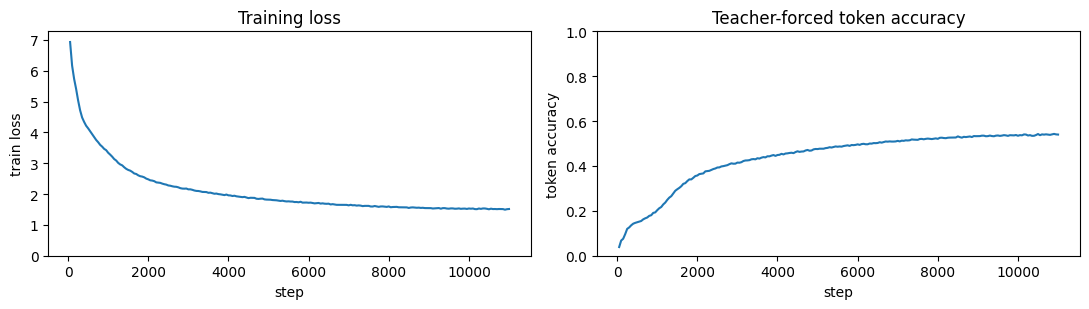

In [ ]:
# Plot loss + accuracy curves.
if history["step"]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    axes[0].plot(history["step"], history["loss"])
    axes[0].set_xlabel("step"); axes[0].set_ylabel("train loss"); axes[0].set_title("Training loss")
    axes[0].set_ylim(0, max(history["loss"]) * 1.05)
    axes[1].plot(history["step"], history["acc"])
    axes[1].set_xlabel("step"); axes[1].set_ylabel("token accuracy"); axes[1].set_title("Teacher-forced token accuracy")
    axes[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()
else:
    print("No training happened (possibly resumed from a completed run).")


## 16d. Load a training checkpoint into the current session state
This overwrites in-memory model/training state so following cells use this checkpoint.

In [ ]:

CUSTOM_NAME = None

if CUSTOM_NAME:
  CKPT_TO_LOAD = CKPT_DIR / f"{CUSTOM_NAME}.pt"
else:
  CKPT_TO_LOAD = CKPT_DIR / f"{config.checkpoint_prefix}_best.pt"

if not CKPT_TO_LOAD.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_TO_LOAD}")

blob = torch.load(CKPT_TO_LOAD, map_location=device)

if isinstance(blob, dict) and "model" in blob:
    model.load_state_dict(blob["model"])
    if "optimizer" in blob:
        optimizer.load_state_dict(blob["optimizer"])
    if "scaler" in blob and "scaler" in globals() and scaler is not None:
        scaler.load_state_dict(blob["scaler"])
    if "step" in blob:
        step = blob["step"]
    if "history" in blob:
        history = blob["history"]
else:
    # Support loading plain state-dict checkpoints
    model.load_state_dict(blob)

model.to(device)
model.eval()

print(f"Loaded checkpoint from {CKPT_TO_LOAD}")
print(f"Model now points to loaded weights on {device}")
if "step" in globals():
    print(f"step = {step}")

## 17. Greedy autoregressive decoding

Matches the paper (Table 3): plain greedy argmax.

We encode the spectrogram **once** and then call the decoder in a loop, feeding the previously-predicted token back in. This is O(N²) in decoder length because we don't cache K/V — fine for our short (≤ ~800-token) sequences. A production inference path would add a KV cache.

Stops at EOS or at `max_length`, whichever comes first.


In [ ]:
# 16d. Load a training checkpoint into the current session state
# This overwrites in-memory model/training state so following cells use this checkpoint.

CKPT_TO_LOAD = CKPT_DIR / f"{config.checkpoint_prefix}_best.pt"

if not CKPT_TO_LOAD.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_TO_LOAD}")

blob = torch.load(CKPT_TO_LOAD, map_location=device)

if isinstance(blob, dict) and "model" in blob:
    model.load_state_dict(blob["model"])
    if "optimizer" in blob:
        optimizer.load_state_dict(blob["optimizer"])
    if "scaler" in blob and "scaler" in globals() and scaler is not None:
        scaler.load_state_dict(blob["scaler"])
    if "step" in blob:
        step = blob["step"]
    if "history" in blob:
        history = blob["history"]
else:
    # Support loading plain state-dict checkpoints
    model.load_state_dict(blob)

model.to(device)
model.eval()

print(f"Loaded checkpoint from {CKPT_TO_LOAD}")
print(f"Model now points to loaded weights on {device}")
if "step" in globals():
    print(f"step = {step}")

In [ ]:
@torch.no_grad()
def greedy_decode(model: PianoTranscriptionTransformer,
                  encoder_input: torch.Tensor,
                  max_length: Optional[int] = None) -> torch.Tensor:
    """encoder_input: [1, input_length, n_mels]. Returns predicted tokens [L_out] (no leading PAD)."""
    model.eval()
    if max_length is None:
        max_length = model.cfg.target_length
    encoded = model.encode(encoder_input)

    tokens = torch.full((1, 1), PAD_ID, device=encoder_input.device, dtype=torch.long)
    for _ in range(max_length - 1):
        logits = model.decode(tokens, encoded)           # [1, t+1, V]
        next_id = int(logits[0, -1].argmax().item())
        tokens = torch.cat(
            [tokens, torch.tensor([[next_id]], device=tokens.device, dtype=torch.long)],
            dim=1,
        )
        if next_id == EOS_ID:
            break
    return tokens[0, 1:]     # drop the initial PAD (decoder-start)


## 18. Turning decoded tokens into notes

Inverse of `tokenize_segment`. Algorithm (paper §3.3):

1. Maintain `current_time` (global seconds) and `current_vel_bin`.
2. Accumulate consecutive shift values. On the first non-shift token, update `current_time` according to `cfg.time_offset_type` (must match what was used during tokenisation):
   - `"absolute"`: `current_time ← segment_time_offset + chain_sum / steps_per_second` (*replace*, not add).
   - `"relative"`: `current_time ← current_time + chain_sum / steps_per_second` (*add*).
3. On a `velocity` token: update `current_vel_bin`.
4. On a `pitch` token:
   - If `current_vel_bin == 0`: note-off. Close the active note of that pitch (if any). Dangling note-offs are silently ignored.
   - Else: note-on. If that pitch is already active, close the old note first, then start a new one. (Paper §3.3.)
5. Active notes returned at segment end are carried into the next segment, which is how notes crossing segment boundaries get closed correctly.


In [ ]:
def decode_events_to_notes(
        event_ids: List[int],
        codec: EventCodec,
        cfg: Config,
        time_offset: float = 0.0,
        initial_active: Optional[Dict[int, Tuple[float, int]]] = None,
) -> Tuple[List[Tuple[float, float, int, int]], Dict[int, Tuple[float, int]]]:
    current_time = time_offset
    current_vel_bin = 0
    active: Dict[int, Tuple[float, int]] = dict(initial_active or {})
    finished: List[Tuple[float, float, int, int]] = []
    chain_sum = 0

    # Inverse of tokenize_segment. Mirrors cfg.time_offset_type:
    #   "absolute": chain_sum is cumulative time from segment start, so
    #     current_time = time_offset + chain_sum / steps_per_second (REPLACE).
    #   "relative": chain_sum is the delta since the previous event, so
    #     current_time += chain_sum / steps_per_second (ADD).
    use_relative = cfg.time_offset_type == "relative"

    for tok in event_ids:
        try:
            etype, val = codec.decode(tok)
        except ValueError:
            continue   # ignore malformed ids

        if etype == "shift":
            chain_sum += val
            continue

        if chain_sum > 0:
            if use_relative:
                current_time += chain_sum / cfg.steps_per_second
            else:
                current_time = time_offset + chain_sum / cfg.steps_per_second
            chain_sum = 0

        if etype == "velocity":
            current_vel_bin = val
        elif etype == "pitch":
            pitch = val
            if current_vel_bin == 0:
                # Note-off.
                if pitch in active:
                    start_t, vel = active.pop(pitch)
                    if current_time > start_t:
                        finished.append((start_t, current_time, pitch, vel))
            else:
                # Note-on. If already active, close first, then restart.
                if pitch in active:
                    start_t, vel = active.pop(pitch)
                    if current_time > start_t:
                        finished.append((start_t, current_time, pitch, vel))
                active[pitch] = (current_time, bin_to_velocity(current_vel_bin, cfg.num_velocity_bins))
    return finished, active


## 19. Full-song transcription

Exactly the inference procedure described in paper §3.3:

1. Split audio into non-overlapping 512-frame (= 4.096 s) segments, zero-padding the last one.
2. For each segment, compute log-mel, run greedy decoding, parse tokens.
3. Thread active notes across segment boundaries so notes longer than one segment get closed correctly.
4. Close any still-active notes at end-of-audio.


In [ ]:
@torch.no_grad()
def transcribe(model: PianoTranscriptionTransformer,
               audio: torch.Tensor,
               cfg: Config,
               codec: EventCodec,
               max_tokens_per_segment: int = 800,
               show_progress: bool = True,
              ) -> List[Tuple[float, float, int, int]]:
    model.eval()
    seg_samples = cfg.segment_samples
    n_segments = max(1, math.ceil(audio.numel() / seg_samples))

    all_notes: List[Tuple[float, float, int, int]] = []
    active: Dict[int, Tuple[float, int]] = {}

    rng = range(n_segments)
    if show_progress:
        rng = tqdm(rng, desc="transcribe", leave=False)

    for i in rng:
        s0 = i * seg_samples
        s1 = min(s0 + seg_samples, audio.numel())
        seg = audio[s0:s1]
        if seg.numel() < seg_samples:
            seg = F.pad(seg, (0, seg_samples - seg.numel()))

        mel = compute_spectrogram(seg)[:cfg.input_length]          # [512, n_mels]
        mel = mel.unsqueeze(0).to(device)                       # [1, 512, n_mels]

        pred_ids = greedy_decode(model, mel, max_length=max_tokens_per_segment).tolist()

        # Strip specials, convert model IDs back to event IDs.
        event_ids: List[int] = []
        for t in pred_ids:
            if t == EOS_ID:
                break
            if t < NUM_SPECIAL:
                continue
            eid = t - NUM_SPECIAL
            if 0 <= eid < codec.num_classes:
                event_ids.append(eid)

        seg_start_sec = s0 / cfg.sample_rate
        finished, active = decode_events_to_notes(
            event_ids, codec, cfg,
            time_offset=seg_start_sec,
            initial_active=active,
        )
        all_notes.extend(finished)

    # Close any still-active notes at the end of the audio.
    end_sec = audio.numel() / cfg.sample_rate
    for pitch, (start_t, vel) in active.items():
        if end_sec > start_t:
            all_notes.append((start_t, end_sec, pitch, vel))

    all_notes.sort()
    return all_notes


## 20a. Standard Evaluation Metrics

Includes same metrics as the paper (§4.2): onset-only F1, onset+offset F1, and onset+offset+velocity F1 — all from `mir_eval.transcription*`. Default tolerance is 50 ms for onsets and `max(50 ms, 20 % of note duration)` for offsets.

Because greedy decoding of a 5-minute piece can take a few minutes, we evaluate on the **first 30 s of each validation piece** by default. Set `duration_sec=None` to do the whole song.


In [ ]:
def _notes_to_arrays(notes):
    if not notes:
        return np.zeros((0, 2)), np.zeros(0), np.zeros(0)
    intervals = np.array([[n[0], n[1]] for n in notes])
    pitch_hz  = 440.0 * (2.0 ** ((np.array([n[2] for n in notes]) - 69) / 12.0))
    velocity  = np.array([n[3] for n in notes])
    return intervals, pitch_hz, velocity


def evaluate_piece(model, piece_cache: Dict, cfg: Config, codec: EventCodec,
                   duration_sec: Optional[float] = 30.0) -> Dict[str, float]:
    audio = load_audio_16k(DATA_DIR / piece_cache["piece"]["audio_filename"])
    if duration_sec is not None:
        audio = audio[: int(duration_sec * cfg.sample_rate)]

    pred_notes = transcribe(model, audio, cfg, codec, show_progress=False)

    gt_notes = piece_cache["notes"]
    if duration_sec is not None:
        gt_notes = [
            (s, min(e, duration_sec), p, v) for s, e, p, v in gt_notes
            if s < duration_sec
        ]

    pred_iv, pred_hz, pred_v = _notes_to_arrays(pred_notes)
    gt_iv,   gt_hz,   gt_v   = _notes_to_arrays(gt_notes)

    if len(gt_iv) == 0 or len(pred_iv) == 0:
        zeros = {"P": 0.0, "R": 0.0, "F": 0.0}
        return {
            "onset":   zeros, "onoff": zeros, "onoffvel": zeros,
            "num_pred": len(pred_notes), "num_gt": len(gt_notes),
        }

    p_on, r_on, f_on, _ = mir_eval.transcription.precision_recall_f1_overlap(
        gt_iv, gt_hz, pred_iv, pred_hz, offset_ratio=None)
    p_off, r_off, f_off, _ = mir_eval.transcription.precision_recall_f1_overlap(
        gt_iv, gt_hz, pred_iv, pred_hz)
    p_vel, r_vel, f_vel, _ = mir_eval.transcription_velocity.precision_recall_f1_overlap(
        gt_iv, gt_hz, gt_v, pred_iv, pred_hz, pred_v)

    return {
        "onset":    {"P": p_on,  "R": r_on,  "F": f_on},
        "onoff":    {"P": p_off, "R": r_off, "F": f_off},
        "onoffvel": {"P": p_vel, "R": r_vel, "F": f_vel},
        "num_pred": len(pred_notes), "num_gt": len(gt_notes),
    }


print("Evaluating on validation set (first 30 s of each piece)...")
results = []
for pc in val_cache:
    r = evaluate_piece(model, pc, config, codec, duration_sec=30.0)
    title = pc["piece"]["canonical_title"][:45]
    print(f"  {title:45s}"
          f"  onset F1 {r['onset']['F']:.3f}"
          f"  on/off F1 {r['onoff']['F']:.3f}"
          f"  on/off/vel F1 {r['onoffvel']['F']:.3f}"
          f"  (pred {r['num_pred']}, gt {r['num_gt']})")
    results.append(r)

mean = lambda key, sub: float(np.mean([r[key][sub] for r in results]))
print("\nMean over validation set:")
print(f"  onset       P {mean('onset','P'):.3f}  R {mean('onset','R'):.3f}  F {mean('onset','F'):.3f}")
print(f"  onset+off   P {mean('onoff','P'):.3f}  R {mean('onoff','R'):.3f}  F {mean('onoff','F'):.3f}")
print(f"  on+off+vel  P {mean('onoffvel','P'):.3f}  R {mean('onoffvel','R'):.3f}  F {mean('onoffvel','F'):.3f}")


Evaluating on validation set (first 30 s of each piece)...
  Mazurka in F Minor, Op. 7, No. 3               onset F1 0.839  on/off F1 0.454  on/off/vel F1 0.390  (pred 196, gt 214)
  Sonata in C Major, D842                        onset F1 0.845  on/off F1 0.506  on/off/vel F1 0.433  (pred 222, gt 244)
  Valse-Impromptu, S. 213                        onset F1 0.848  on/off F1 0.593  on/off/vel F1 0.497  (pred 138, gt 152)
  Etude-Tableaux, Opus 33 No. 3 in C Minor       onset F1 0.708  on/off F1 0.292  on/off/vel F1 0.255  (pred 99, gt 113)
  Sonata No. 27 in E Minor, Op. 90, First Movem  onset F1 0.827  on/off F1 0.423  on/off/vel F1 0.333  (pred 152, gt 160)
  "Der Mueller und der Bach"                     onset F1 0.812  on/off F1 0.130  on/off/vel F1 0.116  (pred 75, gt 63)
  Nocturne in E-flat Major, Op. 55 No. 2         onset F1 0.876  on/off F1 0.466  on/off/vel F1 0.453  (pred 164, gt 158)
  Prelude and Fugue in C-sharp Minor, WTC I      onset F1 0.899  on/off F1 0.428  on/off/v

## 20b. Standard Evaluation Metrics (Test Set)

Copy of the validation evaluation loop from 20a, but run on `test_cache` and report means over the test set.


In [ ]:
print("Evaluating on test set (first 30 s of each piece)...")
results = []
for pc in test_cache:
    r = evaluate_piece(model, pc, config, codec, duration_sec=30.0)
    title = pc["piece"]["canonical_title"][:45]
    print(f"  {title:45s}"
          f"  onset F1 {r['onset']['F']:.3f}"
          f"  on/off F1 {r['onoff']['F']:.3f}"
          f"  on/off/vel F1 {r['onoffvel']['F']:.3f}"
          f"  (pred {r['num_pred']}, gt {r['num_gt']})")
    results.append(r)

mean = lambda key, sub: float(np.mean([r[key][sub] for r in results]))
print("\nMean over test set:")
print(f"  onset       P {mean('onset','P'):.3f}  R {mean('onset','R'):.3f}  F {mean('onset','F'):.3f}")
print(f"  onset+off   P {mean('onoff','P'):.3f}  R {mean('onoff','R'):.3f}  F {mean('onoff','F'):.3f}")
print(f"  on+off+vel  P {mean('onoffvel','P'):.3f}  R {mean('onoffvel','R'):.3f}  F {mean('onoffvel','F'):.3f}")


## 20c. Generate Figures For Experiment 1 & 2 Values (manual input)

This section is a lightweight template for tracking and comparing F1 metrics across baseline and experiment variants.


In [ ]:
# Fill in F1 numbers after each experiment run, then re-run this cell.
exp_results = {
    "Baseline\n(log-mel, 6h)": {"onset": 0.0, "onoff": 0.0, "onoffvel": 0.0},  # Replace with baseline metrics
    "Exp 1\n(STFT, 6h)":       {"onset": 0.0, "onoff": 0.0, "onoffvel": 0.0},  # Replace with experiment 1 metrics
    "Exp 2\n(log-mel, 4h)":    {"onset": 0.0, "onoff": 0.0, "onoffvel": 0.0},  # Replace with experiment 2 metrics
}

labels = list(exp_results.keys())
metrics = ["onset", "onoff", "onoffvel"]
x = np.arange(len(labels)); width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
for i, m in enumerate(metrics):
    ax.bar(x + i*width, [exp_results[l][m] for l in labels], width, label=m)  # One bar group per metric
ax.set_xticks(x + width); ax.set_xticklabels(labels)
ax.set_ylabel("F1"); ax.set_ylim(0, 1); ax.legend()
ax.set_title("Experiment Results")
plt.tight_layout(); plt.savefig("results_comparison.png", dpi=150); plt.show()  # Saves figure and displays it


## 21. Qualitative demo — piano rolls

Transcribe the first 30 s of one validation piece and plot predicted vs ground-truth piano rolls. Ground-truth notes are blue; predictions are overlaid in orange. A good prediction should have most of its orange bars overlap with a blue bar at the same pitch and time.


Transcribing: Johann Sebastian Bach — Prelude and Fugue in F-sharp Minor, WTC II , BWV 883


transcribe:   0%|          | 0/8 [00:00<?, ?it/s]


Predicted 174 notes vs ground truth 175 notes.


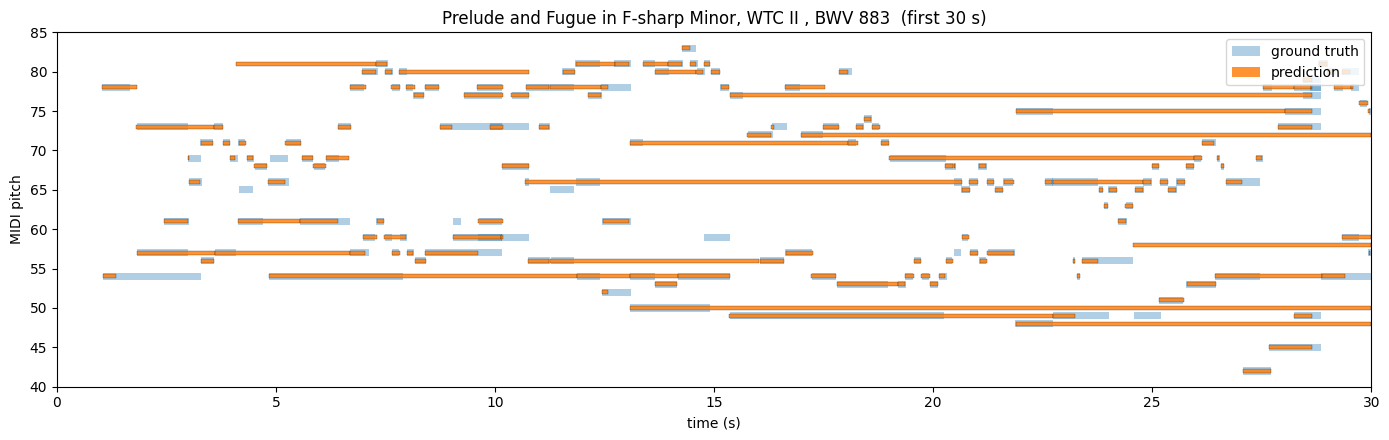

In [ ]:
def plot_piano_roll(gt_notes, pred_notes, title: str = "", duration: float = 30.0):
    from matplotlib.patches import Patch
    fig, ax = plt.subplots(figsize=(14, 4.5))
    for s, e, p, v in gt_notes:
        if s >= duration: continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.45), min(e, duration) - s, 0.9,
            facecolor="tab:blue", alpha=0.35, edgecolor="none"))
    for s, e, p, v in pred_notes:
        if s >= duration: continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.25), min(e, duration) - s, 0.5,
            facecolor="tab:orange", alpha=0.85, edgecolor="k", linewidth=0.2))
    ax.set_xlim(0, duration)
    all_pitches = [n[2] for n in gt_notes + pred_notes]
    if all_pitches:
        ax.set_ylim(min(all_pitches) - 2, max(all_pitches) + 2)
    else:
        ax.set_ylim(20, 109)
    ax.set_xlabel("time (s)"); ax.set_ylabel("MIDI pitch")
    ax.set_title(title)
    ax.legend(handles=[
        Patch(facecolor="tab:blue", alpha=0.35, label="ground truth"),
        Patch(facecolor="tab:orange", alpha=0.85, label="prediction"),
    ], loc="upper right")
    plt.tight_layout(); plt.show()


pc = val_cache[9]
print(f"Transcribing: {pc['piece']['canonical_composer']} — {pc['piece']['canonical_title']}")
audio_full = load_audio_16k(DATA_DIR / pc["piece"]["audio_filename"])
audio_snip = audio_full[: 30 * config.sample_rate]
pred_notes = transcribe(model, audio_snip, config, codec)
gt_notes   = [(s, min(e, 30.0), p, v) for s, e, p, v in pc["notes"] if s < 30.0]

print(f"\nPredicted {len(pred_notes)} notes vs ground truth {len(gt_notes)} notes.")
plot_piano_roll(
    gt_notes, pred_notes,
    title=f"{pc['piece']['canonical_title'][:70]}  (first 30 s)",
    duration=30.0,
)


In [ ]:
#Another cool demo, playing original audio, and then the transciption with computer generated audio
#Lowkey doesnt sound terrible, good show at demo day as well


# =============================================================================
# LISTEN & COMPARE — Play original audio, transcribe, play the result
# =============================================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Audio
import ipywidgets as widgets

# ── Config ────────────────────────────────────────────────────────────────────
PIECE_IDX    = 9      # index into val_cache (0–14)
CLIP_SEC     = 20.0   # how many seconds to use (keep short for faster inference)
# ──────────────────────────────────────────────────────────────────────────────

pc = val_cache[PIECE_IDX]
title_str = f"{pc['piece']['canonical_composer']} — {pc['piece']['canonical_title']}"
print(f"🎵  Piece: {title_str}")
print(f"    Using first {CLIP_SEC:.0f} s\n")

# 1. Load + clip audio
audio_full = load_audio_16k(DATA_DIR / pc["piece"]["audio_filename"])
audio_clip  = audio_full[: int(CLIP_SEC * config.sample_rate)]

# ── ORIGINAL AUDIO ────────────────────────────────────────────────────────────
print("▶  Original audio:")
display(Audio(audio_clip.numpy(), rate=config.sample_rate))

# 2. Transcribe
print("\n⏳  Transcribing…")
pred_notes = transcribe(model, audio_clip, config, codec, show_progress=True)
print(f"✅  Model predicted {len(pred_notes)} notes.")

# 3. Synthesise predicted notes → waveform
#    synthesize_notes() expects [{pitch, start_ms, end_ms, velocity}]
def notes_tuple_to_events(notes):
    """Convert (start_s, end_s, pitch, vel) tuples → synthesize_notes() dicts."""
    return [
        {"pitch": p, "start_ms": s * 1000.0, "end_ms": e * 1000.0, "velocity": v}
        for s, e, p, v in notes
        if e > s
    ]

synth_events = notes_tuple_to_events(pred_notes)
synth_audio  = synthesize_notes(synth_events, sample_rate=config.sample_rate)

# ── TRANSCRIBED (RE-SYNTHESISED) AUDIO ───────────────────────────────────────
print("\n▶  Transcribed audio (model output re-synthesised):")
display(Audio(synth_audio, rate=config.sample_rate))

# 4. Piano-roll comparison
gt_notes = [(s, min(e, CLIP_SEC), p, v)
            for s, e, p, v in pc["notes"] if s < CLIP_SEC]

NOTE_NAMES = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
def pitch_name(m): return f"{NOTE_NAMES[m%12]}{m//12-1}"

fig, ax = plt.subplots(figsize=(15, 4.5))

for s, e, p, v in gt_notes:
    ax.add_patch(plt.Rectangle(
        (s, p - 0.45), min(e, CLIP_SEC) - s, 0.9,
        facecolor="tab:blue", alpha=0.35, edgecolor="none"))

for s, e, p, v in pred_notes:
    if s >= CLIP_SEC: continue
    ax.add_patch(plt.Rectangle(
        (s, p - 0.25), min(e, CLIP_SEC) - s, 0.5,
        facecolor="tab:orange", alpha=0.85, edgecolor="k", linewidth=0.2))

ax.set_xlim(0, CLIP_SEC)
all_p = [n[2] for n in gt_notes + pred_notes]
lo, hi = (min(all_p) - 3, max(all_p) + 3) if all_p else (48, 84)
ax.set_ylim(lo, hi)
c_ticks = [p for p in range(lo, hi+1) if p % 12 == 0]
ax.set_yticks(c_ticks); ax.set_yticklabels([pitch_name(p) for p in c_ticks])
ax.set_xlabel("time (s)"); ax.set_ylabel("MIDI pitch")
ax.set_title(f"{title_str[:70]}  —  GT: {len(gt_notes)} notes  |  Pred: {len(pred_notes)} notes")
ax.legend(handles=[
    Patch(facecolor="tab:blue",   alpha=0.35, label="ground truth"),
    Patch(facecolor="tab:orange", alpha=0.85, label="model prediction"),
], loc="upper right")
plt.tight_layout()
plt.show()

🎵  Piece: Johann Sebastian Bach — Prelude and Fugue in F-sharp Minor, WTC II , BWV 883
    Using first 20 s

▶  Original audio:



⏳  Transcribing…


transcribe:   0%|          | 0/5 [00:00<?, ?it/s]

✅  Model predicted 107 notes.

▶  Transcribed audio (model output re-synthesised):


In [ ]:
# Inspect raw model output on one val segment.
pc = val_cache[0]
audio = load_audio_16k(DATA_DIR / pc["piece"]["audio_filename"])[:config.segment_samples]
mel = compute_spectrogram(audio)[:config.input_length].unsqueeze(0).to(device)

pred = greedy_decode(model, mel, max_length=80).tolist()
print(f"raw tokens ({len(pred)}): {pred[:40]}")
for t in pred[:40]:
    if t == EOS_ID:
        print("  EOS  (stops here)"); break
    if t < NUM_SPECIAL:
        print(f"  special_{t}"); continue
    name, val = codec.decode(t - NUM_SPECIAL)
    print(f"  {name}={val}")

# Also look at the logits at position 0 — what's the model most confident about?
with torch.no_grad():
    enc = model.encode(mel)
    logits0 = model.decode(torch.tensor([[PAD_ID]], device=device), enc)[0, -1]
probs = F.softmax(logits0.float(), dim=-1)
top = probs.topk(10)
print("\ntop-10 first-token predictions:")
for p, i in zip(top.values.tolist(), top.indices.tolist()):
    if i < NUM_SPECIAL:
        print(f"  {p:.3f}  special_{i}")
    else:
        name, v = codec.decode(i - NUM_SPECIAL)
        print(f"  {p:.3f}  {name}={v}")


raw tokens (79): [4, 1132, 1074, 15, 1132, 1074, 19, 1132, 1074, 22, 1132, 1074, 25, 1132, 1074, 25, 1132, 1074, 26, 1132, 1074, 33, 1132, 1074, 42, 1132, 1074, 50, 1132, 1074, 50, 1132, 1074, 50, 1132, 1074, 50, 1132, 1074, 50]
  shift=1
  velocity=0
  pitch=70
  shift=12
  velocity=0
  pitch=70
  shift=16
  velocity=0
  pitch=70
  shift=19
  velocity=0
  pitch=70
  shift=22
  velocity=0
  pitch=70
  shift=22
  velocity=0
  pitch=70
  shift=23
  velocity=0
  pitch=70
  shift=30
  velocity=0
  pitch=70
  shift=39
  velocity=0
  pitch=70
  shift=47
  velocity=0
  pitch=70
  shift=47
  velocity=0
  pitch=70
  shift=47
  velocity=0
  pitch=70
  shift=47
  velocity=0
  pitch=70
  shift=47

top-10 first-token predictions:
  0.124  shift=1
  0.044  shift=2
  0.039  shift=12
  0.038  shift=16
  0.035  shift=4
  0.034  shift=11
  0.032  shift=7
  0.031  shift=15
  0.029  velocity=0
  0.029  shift=3


In [ ]:
# Grab one training sample and decode its target tokens back to notes.
sample = train_ds[0]
target = sample["targets"].tolist()
# Strip specials.
event_ids = []
for t in target:
    if t == EOS_ID: break
    if t < NUM_SPECIAL: continue
    event_ids.append(t - NUM_SPECIAL)

finished, active = decode_events_to_notes(event_ids, codec, config, time_offset=0.0)
print(f"Target sequence decodes to {len(finished)} finished notes + {len(active)} still-active")
for n in finished[:10]:
    print(f"  start={n[0]:.3f}  end={n[1]:.3f}  pitch={n[2]}  vel={n[3]}")
# You should see real musical notes (varying pitches and velocities), confirming
# the training targets ARE well-formed.


Target sequence decodes to 39 finished notes + 1 still-active
  start=0.080  end=0.170  pitch=48  vel=63
  start=0.080  end=0.170  pitch=50  vel=60
  start=0.160  end=0.220  pitch=40  vel=77
  start=0.280  end=0.370  pitch=41  vel=83
  start=0.390  end=0.520  pitch=36  vel=66
  start=0.480  end=0.580  pitch=41  vel=70
  start=0.620  end=0.720  pitch=44  vel=67
  start=0.680  end=0.770  pitch=41  vel=70
  start=0.770  end=0.860  pitch=44  vel=77
  start=0.870  end=1.070  pitch=48  vel=72


In [ ]:
# Teacher-forced evaluation on one val segment.

#Yeah so this not really working, you can see mode collapse

with torch.no_grad():
    pc = val_cache[0]
    # Build the same tensor format as training.
    start_frame = 0
    end_frame = config.input_length
    mel = pc["mel"][start_frame:end_frame].float()
    if mel.size(0) < config.input_length:
        mel = F.pad(mel, (0, 0, 0, config.input_length - mel.size(0)))
    start_sec = 0.0
    end_sec = config.input_length * config.hop_width / config.sample_rate
    event_ids = tokenize_segment(pc["notes"], start_sec, end_sec, codec, config)
    model_ids = [to_model_id(e) for e in event_ids][: config.target_length - 1] + [EOS_ID]
    tgt = torch.full((config.target_length,), PAD_ID, dtype=torch.long)
    tgt[:len(model_ids)] = torch.tensor(model_ids)
    dec_in = shift_right(tgt.unsqueeze(0).to(device))
    mel = mel.unsqueeze(0).to(device)

    logits = model(mel, dec_in)
    preds = logits.argmax(-1)[0]
    tgt_dev = tgt.to(device)
    real_mask = tgt_dev != PAD_ID
    tf_acc = ((preds == tgt_dev) & real_mask).sum().float() / real_mask.sum().float()
    print(f"teacher-forced next-token accuracy on val segment: {tf_acc.item():.3f}")
    # Compare vs marginal-mode baseline: always guess vel=0/pitch=70/shift=1.
    # Also show what the model predicts when forced onto ground truth.
    for i in range(min(20, real_mask.sum().item())):
        t_tok = tgt_dev[i].item(); p_tok = preds[i].item()
        def fmt(x):
            if x == EOS_ID: return "EOS"
            if x == PAD_ID: return "PAD"
            if x < NUM_SPECIAL: return f"spc{x}"
            n, v = codec.decode(x - NUM_SPECIAL); return f"{n}={v}"
        mark = "✓" if t_tok == p_tok else " "
        print(f"  {mark}  target={fmt(t_tok)}   pred={fmt(p_tok)}")


teacher-forced next-token accuracy on val segment: 0.189
     target=shift=100   pred=shift=1
     target=velocity=36   pred=velocity=0
     target=pitch=41   pred=pitch=47
     target=velocity=38   pred=shift=126
     target=pitch=48   pred=pitch=41
     target=shift=117   pred=velocity=37
     target=velocity=39   pred=velocity=0
     target=pitch=40   pred=pitch=48
     target=shift=119   pred=velocity=0
  ✓  target=velocity=0   pred=velocity=0
  ✓  target=pitch=41   pred=pitch=41
     target=shift=133   pred=pitch=41
     target=velocity=44   pred=velocity=0
     target=pitch=36   pred=pitch=41
     target=shift=145   pred=velocity=0
  ✓  target=velocity=0   pred=velocity=0
     target=pitch=40   pred=pitch=39
     target=shift=253   pred=pitch=48
     target=velocity=31   pred=velocity=0
     target=pitch=41   pred=pitch=39


In [ ]:
# Also save the predicted transcription as a MIDI file you can download and play back.
def notes_to_midi(notes, out_path: Path):
    pm = pretty_midi.PrettyMIDI(initial_tempo=120)
    inst = pretty_midi.Instrument(program=0)   # 0 = acoustic grand piano
    for s, e, p, v in notes:
        inst.notes.append(pretty_midi.Note(
            velocity=int(max(1, min(127, v))),
            pitch=int(p),
            start=float(s),
            end=float(max(s + 0.01, e)),
        ))
    pm.instruments.append(inst)
    pm.write(str(out_path))

out_midi = DRIVE_ROOT / "predicted_first_val_piece.mid"
notes_to_midi(pred_notes, out_midi)
print(f"Wrote {out_midi}")


In [ ]:
# =============================================================================
# DEMO CELL 1 — Load the saved checkpoint
# -----------------------------------------------------------------------------
# Run this after your existing setup cells (Config, EventCodec, model definition,
# mel_transform, etc.) are already executed. It loads the config-matched latest checkpoint from Drive.
# =============================================================================

import torch

CUSTOM_NAME = None

if CUSTOM_NAME:
  CKPT_PATH = CKPT_DIR / f"{CUSTOM_NAME}.pt"  # adjust if you saved under a different name
else:
  CKPT_PATH = CKPT_DIR / f"{config.checkpoint_prefix}_latest.pt"  # adjust if you saved under a different name
assert CKPT_PATH.exists(), (
    f"Checkpoint not found at {CKPT_PATH}.\n"
    f"Make sure {CKPT_PATH} is inside {CKPT_DIR} on your Drive."
)

raw = torch.load(str(CKPT_PATH), map_location=device)

# Support both raw state-dict files and wrapped checkpoint dicts
if isinstance(raw, dict):
    sd = (raw.get("model_state_dict")
          or raw.get("model")
          or raw.get("state_dict")
          or raw)
else:
    sd = raw

model.load_state_dict(sd)
model.eval()
print(f"✅  Model loaded from  {CKPT_PATH}")
print(f"    Parameters: {sum(p.numel() for p in model.parameters()):,}")


# =============================================================================
# DEMO CELL 2  (REPLACE the previous Cell 2)
# Register the Python-side transcription callback
# =============================================================================

import json

    gt_notes = piece_cache["notes"]
    if duration_sec is not None:
from matplotlib.patches import Patch
import torch
from IPython.display import clear_output
from google.colab import output


# ── Audio synthesis ──────────────────────────────────────────────────────────

def synthesize_notes(note_events: list, sample_rate: int = 16_000) -> np.ndarray:
    """
    Convert [{pitch, start_ms, end_ms, velocity}] → float32 waveform at sample_rate.

    Multi-harmonic additive synthesis + per-note ADSR envelope.
    Matches the 16 kHz mono format the model was trained on.
    """
    if not note_events:
        return np.zeros(sample_rate, dtype=np.float32)

    total_sec     = max(n["end_ms"] for n in note_events) / 1000.0 + 0.3
    total_samples = int(total_sec * sample_rate)
    audio         = np.zeros(total_samples, dtype=np.float64)

    # Harmonic series amplitudes (approximates piano brightness)
    PARTIALS     = [1, 2, 3, 4, 5, 6]
    PARTIAL_AMPS = [1.0, 0.55, 0.30, 0.15, 0.08, 0.04]
    AMP_SUM      = sum(PARTIAL_AMPS)
    DECAY_RATE   = 3.5   # amplitude e-folds per second
    ATTACK_SEC   = 0.008 # 8 ms linear attack

    for note in note_events:
        pitch    = int(note["pitch"])
        start_s  = note["start_ms"] / 1000.0
        end_s    = note["end_ms"]   / 1000.0
        velocity = float(note.get("velocity", 80)) / 127.0

        freq = 440.0 * (2.0 ** ((pitch - 69) / 12.0))
        i0   = int(start_s * sample_rate)
        i1   = min(int(end_s * sample_rate), total_samples)
        if i1 <= i0:
            continue

        t = np.arange(i1 - i0) / sample_rate

        # Additive synthesis
        tone = sum(
            amp * np.sin(2 * np.pi * k * freq * t)
            for k, amp in zip(PARTIALS, PARTIAL_AMPS)
        ) / AMP_SUM

        # Envelope: short attack then exponential decay
        envelope = np.minimum(t / ATTACK_SEC, 1.0) * np.exp(-DECAY_RATE * t)
        audio[i0:i1] += tone * envelope * velocity

    # Peak-normalise to 0.85 FS
    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak * 0.85

    return audio.astype(np.float32)


# ── Piano-roll plot  (same style as the notebook's plot_piano_roll) ──────────

NOTE_NAMES = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]

def pitch_name(midi: int) -> str:
    return f"{NOTE_NAMES[midi % 12]}{midi // 12 - 1}"

def plot_piano_roll_demo(gt_notes, pred_notes, duration: float, title: str = ""):
    """
    Identical layout to the notebook's plot_piano_roll:
      - Ground truth  : wide tab:blue rectangles (alpha 0.35)
      - Prediction    : narrow tab:orange rectangles on top (alpha 0.85)
    Both drawn on a single axis so overlaps are visible.
    """
    fig, ax = plt.subplots(figsize=(14, 4.5))

    # Ground-truth notes (wide, behind)
    for s, e, p, v in gt_notes:
        if s >= duration:
            continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.45), min(e, duration) - s, 0.9,
            facecolor="tab:blue", alpha=0.35, edgecolor="none"
        ))

    # Predicted notes (narrow, in front)
    for s, e, p, v in pred_notes:
        if s >= duration:
            continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.25), min(e, duration) - s, 0.5,
            facecolor="tab:orange", alpha=0.85, edgecolor="k", linewidth=0.2
        ))

    ax.set_xlim(0, duration)

    all_pitches = [n[2] for n in gt_notes + pred_notes]
    if all_pitches:
        lo = min(all_pitches) - 3
        hi = max(all_pitches) + 3
    else:
        lo, hi = 48, 84
    ax.set_ylim(lo, hi)

    # Y-axis: label every C note
    c_ticks = [p for p in range(lo, hi + 1) if p % 12 == 0]
    ax.set_yticks(c_ticks)
    ax.set_yticklabels([pitch_name(p) for p in c_ticks])

    ax.set_xlabel("time (s)")
    ax.set_ylabel("MIDI pitch")
    ax.set_title(title or "Piano Transcription Demo")
    ax.legend(
        handles=[
            Patch(facecolor="tab:blue",   alpha=0.35, label="ground truth (keys played)"),
            Patch(facecolor="tab:orange", alpha=0.85, label="model prediction"),
        ],
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()


# ── Colab callback ────────────────────────────────────────────────────────────

def handle_transcription(notes_json: str):
    """
    Called from the JS piano widget.
    Receives JSON list of {pitch, start_ms, end_ms, velocity}, synthesises
    audio, runs the model, and renders the piano-roll comparison.
    """
    note_events = json.loads(notes_json)

    if not note_events:
        print("⚠️  No notes recorded — play something first!")
        return

    # Build ground-truth note list from the key-press events
    gt_notes = [
        (n["start_ms"] / 1000.0,
         n["end_ms"]   / 1000.0,
         int(n["pitch"]),
         int(n.get("velocity", 80)))
        for n in note_events
        if n["end_ms"] > n["start_ms"]
    ]

    # Synthesise audio and run model
    audio_np     = synthesize_notes(note_events, sample_rate=config.sample_rate)
    duration_sec = len(audio_np) / config.sample_rate
    audio_t      = torch.from_numpy(audio_np)
    pred_notes   = transcribe(model, audio_t, config, codec, show_progress=False)

    # Show piano-roll comparison (visual only — no text dumps)
    clear_output(wait=True)
    title = (f"Ground Truth: {len(gt_notes)} note(s)   |   "
             f"Model Prediction: {len(pred_notes)} note(s)   |   "
             f"Clip: {duration_sec:.2f} s")
    plot_piano_roll_demo(gt_notes, pred_notes, duration=duration_sec, title=title)


output.register_callback("notebook.transcribe", handle_transcription)
print("✅  Callback registered — run Cell 3 to open the piano.")

# =============================================================================
# DEMO CELL 3 — Interactive piano widget
# -----------------------------------------------------------------------------
# Displays a 3-octave piano (C3–B5, MIDI 48–83) with:
#   • Click or keyboard shortcuts to play notes
#   • Visual key highlighting while held
#   • Web-Audio synthesis (multi-harmonic + ADSR envelope)
#   • Note timeline list
#   • "Transcribe" button → sends events to Python callback above
# =============================================================================

from IPython.display import display, HTML

_PIANO_HTML = r"""
<style>
  /* ── Layout ── */
  #piano-wrap {
    font-family: 'Segoe UI', system-ui, sans-serif;
    background: #1e1e2e;
    border-radius: 12px;
    padding: 20px 24px 18px;
    width: fit-content;
    max-width: 100%;
    box-shadow: 0 8px 32px rgba(0,0,0,.5);
    color: #cdd6f4;
    user-select: none;
  }
  h3 { margin: 0 0 12px; font-size: 15px; color: #89b4fa; letter-spacing: .5px; }

  /* ── Piano keyboard ── */
  #keyboard { position: relative; display: flex; height: 130px; margin-bottom: 16px; }

  .wkey {
    position: relative;
    width: 36px; height: 130px;
    background: linear-gradient(to bottom, #f0f0f0, #e0e0e0);
    border: 1px solid #999;
    border-radius: 0 0 6px 6px;
    cursor: pointer;
    box-sizing: border-box;
    transition: background .05s;
    flex-shrink: 0;
  }
  .wkey:hover   { background: #d8ecff; }
  .wkey.active  { background: #89b4fa; box-shadow: inset 0 -4px 6px rgba(0,0,0,.25); }

  .bkey {
    position: absolute;
    width: 22px; height: 80px;
    background: linear-gradient(to bottom, #222, #111);
    border-radius: 0 0 4px 4px;
    cursor: pointer;
    z-index: 2;
    box-shadow: 2px 4px 6px rgba(0,0,0,.6);
    transition: background .05s;
    top: 0;
  }
  .bkey:hover   { background: linear-gradient(to bottom,#444,#222); }
  .bkey.active  { background: linear-gradient(to bottom,#7ba1e0,#4a7abd);
                  box-shadow: 1px 2px 3px rgba(0,0,0,.4); }

  /* note label on white key */
  .wkey .label { position: absolute; bottom: 5px; left: 50%; transform: translateX(-50%);
                  font-size: 9px; color: #888; pointer-events: none; }
  .wkey.c-key .label { color: #555; font-weight: 600; font-size: 10px; }

  /* ── Controls ── */
  #controls { display: flex; gap: 10px; align-items: center; flex-wrap: wrap; }

  button {
    padding: 8px 18px;
    border: none; border-radius: 8px;
    font-size: 13px; font-weight: 600;
    cursor: pointer; transition: opacity .15s, transform .1s;
  }
  button:active { transform: scale(.96); }
  #btn-transcribe { background: #89b4fa; color: #1e1e2e; }
  #btn-clear      { background: #f38ba8; color: #1e1e2e; }
  #btn-transcribe:disabled { opacity: .4; cursor: default; }

  #status {
    font-size: 12px; color: #a6adc8;
    flex: 1; min-width: 160px;
  }
  #rec-dot {
    display: inline-block; width: 9px; height: 9px;
    background: #f38ba8; border-radius: 50%;
    margin-right: 5px; animation: pulse 1s infinite;
    visibility: hidden;
  }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:.3} }

  /* ── Note log ── */
  #note-log {
    margin-top: 14px;
    max-height: 80px;
    overflow-y: auto;
    font-size: 11px;
    color: #6c7086;
    background: #181825;
    border-radius: 6px;
    padding: 6px 8px;
  }
  #note-log span { display: inline-block; margin: 1px 4px;
                   background: #313244; border-radius: 4px; padding: 1px 5px; }
  #note-log.has-notes { color: #a6adc8; }

  /* ── Keyboard shortcut hint ── */
  #kbd-hint {
    margin-top: 10px; font-size: 10px; color: #45475a;
    line-height: 1.6;
  }
</style>

<div id="piano-wrap">
  <h3>🎹  Piano Transcription Demo</h3>

  <div id="keyboard"></div>

  <div id="controls">
    <button id="btn-transcribe" disabled>Transcribe ▶</button>
    <button id="btn-clear">Clear</button>
    <span id="status"><span id="rec-dot"></span><span id="status-text">Play some notes, then click Transcribe.</span></span>
  </div>

  <div id="note-log">Notes will appear here as you play…</div>

  <div id="kbd-hint">
    Keyboard shortcuts — lower row: <b>A S D F G H J K L ;</b>  /  upper row: <b>W E T Y U O P</b>
  </div>
</div>

<script>
(function () {
  /* ── 1.  Pitch layout  C3(48) → B5(83)  ──────────────────────────────── */
  const START_MIDI = 48;   // C3
  const END_MIDI   = 83;   // B5

  // Chromatic semitone → white-key position within octave (null = black key)
  const WHITE_POS = [0,null,1,null,2,3,null,4,null,5,null,6]; // C..B
  // Black-key offset from preceding white key (in px, from left edge of white key)
  const BLACK_OFF = {1:23, 3:23, 6:23, 8:23, 10:23};

  const NOTE_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'];
  const WHITE_KEY_W = 36;

  /* ── 2.  Build DOM  ─────────────────────────────────────────────────────── */
  const keyboard = document.getElementById('keyboard');
  const noteLog  = document.getElementById('note-log');
  const btnTx    = document.getElementById('btn-transcribe');
  const btnCl    = document.getElementById('btn-clear');
  const recDot   = document.getElementById('rec-dot');
  const statusTx = document.getElementById('status-text');

  const keyEls   = {};     // midi -> element
  let whiteCount = 0;
  const blackQueue = [];   // deferred black-key placement

  for (let midi = START_MIDI; midi <= END_MIDI; midi++) {
    const semi  = midi % 12;
    const wpos  = WHITE_POS[semi];
    const isBlack = (wpos === null);
    const el    = document.createElement('div');

    if (!isBlack) {
      el.className = 'wkey' + (semi === 0 ? ' c-key' : '');
      const lbl = document.createElement('span');
      lbl.className = 'label';
      lbl.textContent = (semi === 0) ? NOTE_NAMES[semi] + (Math.floor(midi/12)-1) : NOTE_NAMES[semi];
      el.appendChild(lbl);
      keyboard.appendChild(el);
      whiteCount++;
    } else {
      el.className = 'bkey';
      blackQueue.push({el, midi});
    }
    el.dataset.midi = midi;
    keyEls[midi] = el;
  }

  // Re-scan and position black keys
  // We need the white-key x positions first
  const wEls = [...keyboard.querySelectorAll('.wkey')];
  // Map midi -> x offset of its white element (or preceding white)
  const midiToX = {};
  let wIdx = 0;
  for (let midi = START_MIDI; midi <= END_MIDI; midi++) {
    const semi = midi % 12;
    if (WHITE_POS[semi] !== null) {
      midiToX[midi] = wIdx * WHITE_KEY_W;
      wIdx++;
    }
  }
  // Black keys: position relative to the white key to their left
  for (let midi = START_MIDI; midi <= END_MIDI; midi++) {
    const semi = midi % 12;
    if (WHITE_POS[semi] !== null) continue;
    // Find x of prev white key
    const prevX = midiToX[midi - 1];  // always a white key just before
    const el = keyEls[midi];
    el.style.left = (prevX + BLACK_OFF[semi] - 1) + 'px';
    keyboard.appendChild(el);
  }

  // Set keyboard total width
  keyboard.style.width = (whiteCount * WHITE_KEY_W) + 'px';

  /* ── 3.  Web Audio synthesis  ──────────────────────────────────────────── */
  let audioCtx = null;
  const activeOscillators = {};  // midi -> {oscs, gain, startTime}

  function getCtx() {
    if (!audioCtx) audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    if (audioCtx.state === 'suspended') audioCtx.resume();
    return audioCtx;
  }

  function midiToFreq(midi) {
    return 440 * Math.pow(2, (midi - 69) / 12);
  }

  function noteOn(midi) {
    if (activeOscillators[midi]) return;
    const ctx  = getCtx();
    const freq = midiToFreq(midi);
    const vel  = 0.7;

    const masterGain = ctx.createGain();
    masterGain.gain.setValueAtTime(0, ctx.currentTime);
    masterGain.gain.linearRampToValueAtTime(vel * 0.3, ctx.currentTime + 0.008);
    masterGain.connect(ctx.destination);

    const PARTIALS = [
      {k:1, amp:1.0}, {k:2, amp:0.45}, {k:3, amp:0.20},
      {k:4, amp:0.10}, {k:5, amp:0.05}
    ];
    const oscs = PARTIALS.map(({k, amp}) => {
      const osc = ctx.createOscillator();
      osc.type = 'sine';
      osc.frequency.value = freq * k;
      const g = ctx.createGain();
      g.gain.setValueAtTime(amp, ctx.currentTime);
      // per-partial decay
      g.gain.exponentialRampToValueAtTime(amp * 0.001, ctx.currentTime + 6);
      osc.connect(g);
      g.connect(masterGain);
      osc.start();
      return osc;
    });

    activeOscillators[midi] = {oscs, gain: masterGain};
  }

  function noteOff(midi) {
    const obj = activeOscillators[midi];
    if (!obj) return;
    const ctx = getCtx();
    obj.gain.gain.cancelScheduledValues(ctx.currentTime);
    obj.gain.gain.setValueAtTime(obj.gain.gain.value, ctx.currentTime);
    obj.gain.gain.exponentialRampToValueAtTime(0.001, ctx.currentTime + 0.06);
    obj.oscs.forEach(o => o.stop(ctx.currentTime + 0.08));
    delete activeOscillators[midi];
  }

  /* ── 4.  Note recording  ────────────────────────────────────────────────── */
  let recordedNotes = [];    // [{pitch, start_ms, end_ms, velocity}]
  let activePress   = {};    // midi -> {startMs}
  let recordStart   = null;  // Date.now() when first note began

  function pressKey(midi) {
    if (activePress[midi]) return;
    if (recordStart === null) recordStart = Date.now();
    activePress[midi] = {startMs: Date.now() - recordStart};
    noteOn(midi);
    keyEls[midi] && keyEls[midi].classList.add('active');
    recDot.style.visibility = 'visible';
    statusTx.textContent = `Playing… (${Object.keys(activePress).length} key(s) held)`;
  }

  function releaseKey(midi) {
    const p = activePress[midi];
    if (!p) return;
    const endMs = Date.now() - recordStart;
    recordedNotes.push({
      pitch:    midi,
      start_ms: p.startMs,
      end_ms:   endMs,
      velocity: 80
    });
    delete activePress[midi];
    noteOff(midi);
    keyEls[midi] && keyEls[midi].classList.remove('active');

    // Update log
    const name = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'][midi%12]
                 + String(Math.floor(midi/12)-1);
    noteLog.innerHTML = noteLog.innerHTML.replace('Notes will appear here as you play…','');
    noteLog.classList.add('has-notes');
    noteLog.innerHTML += `<span>${name} ${(endMs/1000).toFixed(2)}s</span>`;
    noteLog.scrollLeft = noteLog.scrollWidth;

    if (Object.keys(activePress).length === 0) {
      recDot.style.visibility = 'hidden';
      statusTx.textContent = `${recordedNotes.length} note(s) recorded. Ready to transcribe!`;
      btnTx.disabled = false;
    }
  }

  /* ── 5.  Release all active keys (safety) ─────────────────────────────── */
  function releaseAll() {
    Object.keys(activePress).forEach(midi => releaseKey(Number(midi)));
  }

  /* ── 6.  Mouse / touch events  ─────────────────────────────────────────── */
  keyboard.addEventListener('mousedown', e => {
    const el = e.target.closest('[data-midi]');
    if (el) pressKey(Number(el.dataset.midi));
  });
  document.addEventListener('mouseup', releaseAll);
  keyboard.addEventListener('touchstart', e => {
    e.preventDefault();
    [...e.changedTouches].forEach(t => {
      const el = document.elementFromPoint(t.clientX, t.clientY);
      if (el && el.dataset.midi) pressKey(Number(el.dataset.midi));
    });
  }, {passive: false});
  document.addEventListener('touchend', e => {
    [...e.changedTouches].forEach(t => {
      const el = document.elementFromPoint(t.clientX, t.clientY);
      if (el && el.dataset.midi) releaseKey(Number(el.dataset.midi));
    });
    releaseAll();
  });

  /* ── 7.  Keyboard shortcuts (two rows)  ───────────────────────────────── */
  // Lower row keys map to white keys from C3 upward
  const KEY_MAP_LOWER = 'asdfghjkl;';   // C3 D3 E3 F3 G3 A3 B3 C4 D4 E4
  const KEY_MAP_UPPER = 'wetyu op';     // C#3 D#3 _ F#3 G#3 _ A#3 _ C#4 D#4
  // White MIDI sequence
  const whiteMidis = [];
  for (let m = START_MIDI; m <= END_MIDI; m++) {
    if (WHITE_POS[m % 12] !== null) whiteMidis.push(m);
  }
  // Black MIDI sequence (only the ones above white keys 0..n-2)
  const blackMidis = [];
  for (let m = START_MIDI; m <= END_MIDI; m++) {
    if (WHITE_POS[m % 12] === null) blackMidis.push(m);
  }

  const kbMap = {};
  KEY_MAP_LOWER.split('').forEach((k, i) => { if (whiteMidis[i]) kbMap[k] = whiteMidis[i]; });
  KEY_MAP_UPPER.split('').forEach((k, i) => { if (k !== ' ' && blackMidis[i]) kbMap[k] = blackMidis[i]; });

  const heldKeys = new Set();
  document.addEventListener('keydown', e => {
    if (e.repeat || e.ctrlKey || e.metaKey || e.altKey) return;
    const midi = kbMap[e.key.toLowerCase()];
    if (midi && !heldKeys.has(e.key)) {
      heldKeys.add(e.key);
      pressKey(midi);
    }
  });
  document.addEventListener('keyup', e => {
    const midi = kbMap[e.key.toLowerCase()];
    if (midi) {
      heldKeys.delete(e.key);
      releaseKey(midi);
    }
  });

  /* ── 8.  Buttons  ──────────────────────────────────────────────────────── */
  btnCl.addEventListener('click', () => {
    releaseAll();
    recordedNotes = [];
    activePress   = {};
    recordStart   = null;
    noteLog.innerHTML = 'Notes will appear here as you play…';
    noteLog.classList.remove('has-notes');
    recDot.style.visibility = 'hidden';
    statusTx.textContent = 'Cleared. Play some notes, then click Transcribe.';
    btnTx.disabled = true;
  });

  btnTx.addEventListener('click', () => {
    releaseAll();
    if (recordedNotes.length === 0) {
      statusTx.textContent = '⚠️  No notes to transcribe!';
      return;
    }
    btnTx.disabled = true;
    statusTx.textContent = '⏳  Sending to Python…';
    const payload = JSON.stringify(recordedNotes);
    google.colab.kernel.invokeFunction('notebook.transcribe', [payload], {});
  });

})();
</script>
"""

display(HTML(_PIANO_HTML))

✅  Model loaded from  /content/drive/MyDrive/piano_transcription/checkpoints/latest.pt
    Parameters: 45,634,560
✅  Callback registered — run Cell 3 to open the piano.


In [ ]:

import torch

CUSTOM_NAME = None # adjust if you want different name

if CUSTOM_NAME:
  CKPT_PATH = CKPT_DIR / f"{CUSTOM_NAME}.pt" 
else:
  CKPT_PATH = CKPT_DIR / f"{config.checkpoint_prefix}_latest.pt" 
assert CKPT_PATH.exists(), (
    f"Checkpoint not found at {CKPT_PATH}.\n"
    f"Make sure {CKPT_PATH} is inside {CKPT_DIR} on your Drive."
)

raw = torch.load(str(CKPT_PATH), map_location=device)

# Support raw state-dicts and wrapped checkpoint dicts
if isinstance(raw, dict):
    sd = (raw.get("model_state_dict")
          or raw.get("model")
          or raw.get("state_dict")
          or raw)
else:
    sd = raw

model.load_state_dict(sd)
model.eval()
print(f"✅  Model loaded from {CKPT_PATH}")
print(f"    Parameters: {sum(p.numel() for p in model.parameters()):,}")



In [ ]:

# =============================================================================
# DEMO CELL 2 — Python callback: synthesise → transcribe → plot
# =============================================================================

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch
from google.colab import output


# ── Audio synthesis ──────────────────────────────────────────────────────────

def synthesize_notes(note_events: list, sample_rate: int = 16_000) -> np.ndarray:
    if not note_events:
        return np.zeros(sample_rate, dtype=np.float32)

    total_sec     = max(n["end_ms"] for n in note_events) / 1000.0 + 0.3
    total_samples = int(total_sec * sample_rate)
    audio         = np.zeros(total_samples, dtype=np.float64)

    PARTIALS     = [1, 2, 3, 4, 5, 6]
    PARTIAL_AMPS = [1.0, 0.55, 0.30, 0.15, 0.08, 0.04]
    AMP_SUM      = sum(PARTIAL_AMPS)

    for note in note_events:
        pitch    = int(note["pitch"])
        start_s  = note["start_ms"] / 1000.0
        end_s    = note["end_ms"]   / 1000.0
        velocity = float(note.get("velocity", 80)) / 127.0

        freq = 440.0 * (2.0 ** ((pitch - 69) / 12.0))
        i0   = int(start_s * sample_rate)
        i1   = min(int(end_s * sample_rate), total_samples)
        if i1 <= i0:
            continue

        t        = np.arange(i1 - i0) / sample_rate
        tone     = sum(amp * np.sin(2 * np.pi * k * freq * t)
                       for k, amp in zip(PARTIALS, PARTIAL_AMPS)) / AMP_SUM
        envelope = np.minimum(t / 0.008, 1.0) * np.exp(-3.5 * t)
        audio[i0:i1] += tone * envelope * velocity

    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak * 0.85

    return audio.astype(np.float32)


# ── Piano-roll plot (matches notebook's plot_piano_roll exactly) ─────────────

NOTE_NAMES = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]

def pitch_name(midi: int) -> str:
    return f"{NOTE_NAMES[midi % 12]}{midi // 12 - 1}"

def plot_piano_roll_demo(gt_notes, pred_notes, duration: float, title: str = ""):
    fig, ax = plt.subplots(figsize=(14, 4.5))

    for s, e, p, v in gt_notes:
        if s >= duration:
            continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.45), min(e, duration) - s, 0.9,
            facecolor="tab:blue", alpha=0.35, edgecolor="none"
        ))

    for s, e, p, v in pred_notes:
        if s >= duration:
            continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.25), min(e, duration) - s, 0.5,
            facecolor="tab:orange", alpha=0.85, edgecolor="k", linewidth=0.2
        ))

    ax.set_xlim(0, duration)

    all_pitches = [n[2] for n in gt_notes + pred_notes]
    lo = (min(all_pitches) - 3) if all_pitches else 48
    hi = (max(all_pitches) + 3) if all_pitches else 84
    ax.set_ylim(lo, hi)

    c_ticks = [p for p in range(lo, hi + 1) if p % 12 == 0]
    ax.set_yticks(c_ticks)
    ax.set_yticklabels([pitch_name(p) for p in c_ticks])

    ax.set_xlabel("time (s)")
    ax.set_ylabel("MIDI pitch")
    ax.set_title(title or "Piano Transcription Demo")
    ax.legend(handles=[
        Patch(facecolor="tab:blue",   alpha=0.35, label="ground truth (keys played)"),
        Patch(facecolor="tab:orange", alpha=0.85, label="model prediction"),
    ], loc="upper right")

    plt.tight_layout()
    plt.show()


# ── Callback ─────────────────────────────────────────────────────────────────

def handle_transcription(notes_json: str):
    try:
        note_events = json.loads(notes_json)

        if not note_events:
            print("⚠️  No notes recorded — play something first!")
            return

        gt_notes = [
            (n["start_ms"] / 1000.0,
             n["end_ms"]   / 1000.0,
             int(n["pitch"]),
             int(n.get("velocity", 80)))
            for n in note_events
            if n["end_ms"] > n["start_ms"]
        ]

        audio_np     = synthesize_notes(note_events, sample_rate=config.sample_rate)
        duration_sec = len(audio_np) / config.sample_rate
        audio_t      = torch.from_numpy(audio_np)
        pred_notes   = transcribe(model, audio_t, config, codec, show_progress=False)

        title = (f"Ground Truth: {len(gt_notes)} note(s)   |   "
                 f"Model Prediction: {len(pred_notes)} note(s)   |   "
                 f"Clip: {duration_sec:.2f} s")
        plot_piano_roll_demo(gt_notes, pred_notes, duration=duration_sec, title=title)

    except Exception as e:
        import traceback
        print(f"❌ Error during transcription: {e}")
        traceback.print_exc()


output.register_callback("notebook.transcribe", handle_transcription)
print("✅  Callback registered — run Cell 3 to open the piano.")



✅  Callback registered — run Cell 3 to open the piano.


In [ ]:

# =============================================================================
# DEMO CELL 3 — Interactive piano widget
# =============================================================================

from IPython.display import display, HTML

_PIANO_HTML = r"""
<style>
  #piano-wrap {
    font-family: 'Segoe UI', system-ui, sans-serif;
    background: #1e1e2e;
    border-radius: 12px;
    padding: 20px 24px 18px;
    width: fit-content;
    max-width: 100%;
    box-shadow: 0 8px 32px rgba(0,0,0,.5);
    color: #cdd6f4;
    user-select: none;
  }
  h3 { margin: 0 0 12px; font-size: 15px; color: #89b4fa; letter-spacing: .5px; }

  #keyboard { position: relative; display: flex; height: 130px; margin-bottom: 16px; }

  .wkey {
    position: relative;
    width: 36px; height: 130px;
    background: linear-gradient(to bottom, #f0f0f0, #e0e0e0);
    border: 1px solid #999;
    border-radius: 0 0 6px 6px;
    cursor: pointer;
    box-sizing: border-box;
    flex-shrink: 0;
    transition: background .05s;
  }
  .wkey:hover  { background: #d8ecff; }
  .wkey.active { background: #89b4fa; box-shadow: inset 0 -4px 6px rgba(0,0,0,.25); }

  .bkey {
    position: absolute;
    width: 22px; height: 80px;
    background: linear-gradient(to bottom, #222, #111);
    border-radius: 0 0 4px 4px;
    cursor: pointer;
    z-index: 2;
    box-shadow: 2px 4px 6px rgba(0,0,0,.6);
    transition: background .05s;
    top: 0;
  }
  .bkey:hover  { background: linear-gradient(to bottom,#444,#222); }
  .bkey.active { background: linear-gradient(to bottom,#7ba1e0,#4a7abd); }

  .wkey .label {
    position: absolute; bottom: 5px; left: 50%;
    transform: translateX(-50%);
    font-size: 9px; color: #888; pointer-events: none;
  }
  .wkey.c-key .label { color: #444; font-weight: 700; font-size: 10px; }

  #controls { display: flex; gap: 10px; align-items: center; flex-wrap: wrap; }

  button {
    padding: 8px 18px;
    border: none; border-radius: 8px;
    font-size: 13px; font-weight: 600;
    cursor: pointer;
    transition: opacity .15s, transform .1s;
  }
  button:active  { transform: scale(.96); }
  button:disabled { opacity: .4; cursor: default; }
  #btn-transcribe { background: #89b4fa; color: #1e1e2e; }
  #btn-clear      { background: #f38ba8; color: #1e1e2e; }

  #status {
    font-size: 12px; color: #a6adc8;
    flex: 1; min-width: 180px;
  }
  #rec-dot {
    display: inline-block; width: 9px; height: 9px;
    background: #f38ba8; border-radius: 50%;
    margin-right: 5px;
    animation: pulse 1s infinite;
    visibility: hidden;
  }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:.3} }

  #note-log {
    margin-top: 14px;
    max-height: 70px;
    overflow-y: auto;
    font-size: 11px;
    color: #6c7086;
    background: #181825;
    border-radius: 6px;
    padding: 6px 8px;
    line-height: 1.8;
  }
  #note-log span {
    display: inline-block;
    margin: 1px 3px;
    background: #313244;
    border-radius: 4px;
    padding: 1px 5px;
    color: #a6adc8;
  }

  #kbd-hint { margin-top: 10px; font-size: 10px; color: #45475a; }
</style>

<div id="piano-wrap">
  <h3>🎹  Piano Transcription Demo</h3>
  <div id="keyboard"></div>
  <div id="controls">
    <button id="btn-transcribe" disabled>Transcribe ▶</button>
    <button id="btn-clear">Clear</button>
    <span id="status">
      <span id="rec-dot"></span>
      <span id="status-text">Play some notes, then click Transcribe.</span>
    </span>
  </div>
  <div id="note-log">Notes will appear here as you play…</div>
  <div id="kbd-hint">
    White keys: <b>A S D F G H J K L ;</b> &nbsp;|&nbsp; Black keys: <b>W E T Y U O P</b>
  </div>
</div>

<script>
(function () {

  // ── Pitch layout: C3 (48) → B5 (83) ──────────────────────────────────────
  const START_MIDI  = 48;
  const END_MIDI    = 83;
  const WHITE_POS   = [0,null,1,null,2,3,null,4,null,5,null,6]; // semitone → white slot
  const NOTE_NAMES  = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'];
  const WHITE_KEY_W = 36;
  // Left-offset of a black key relative to its preceding white key
  const BLACK_DELTA = 23;

  // ── Build DOM ─────────────────────────────────────────────────────────────
  const keyboard  = document.getElementById('keyboard');
  const noteLog   = document.getElementById('note-log');
  const btnTx     = document.getElementById('btn-transcribe');
  const btnCl     = document.getElementById('btn-clear');
  const recDot    = document.getElementById('rec-dot');
  const statusTxt = document.getElementById('status-text');

  const keyEls  = {};
  let whiteIdx  = 0;
  const midiToWhiteX = {};

  // First pass: white keys (laid out in flex row)
  for (let midi = START_MIDI; midi <= END_MIDI; midi++) {
    const semi = midi % 12;
    if (WHITE_POS[semi] === null) continue;
    const el = document.createElement('div');
    el.className = 'wkey' + (semi === 0 ? ' c-key' : '');
    el.dataset.midi = midi;
    const lbl = document.createElement('span');
    lbl.className = 'label';
    lbl.textContent = semi === 0 ? NOTE_NAMES[semi] + (Math.floor(midi/12)-1) : NOTE_NAMES[semi];
    el.appendChild(lbl);
    keyboard.appendChild(el);
    midiToWhiteX[midi] = whiteIdx * WHITE_KEY_W;
    keyEls[midi] = el;
    whiteIdx++;
  }
  keyboard.style.width = (whiteIdx * WHITE_KEY_W) + 'px';

  // Second pass: black keys (absolutely positioned)
  for (let midi = START_MIDI; midi <= END_MIDI; midi++) {
    const semi = midi % 12;
    if (WHITE_POS[semi] !== null) continue;
    const prevWhiteX = midiToWhiteX[midi - 1];
    const el = document.createElement('div');
    el.className = 'bkey';
    el.dataset.midi = midi;
    el.style.left = (prevWhiteX + BLACK_DELTA) + 'px';
    keyboard.appendChild(el);
    keyEls[midi] = el;
  }

  // ── Web Audio synthesis ───────────────────────────────────────────────────
  let audioCtx = null;
  const activeNodes = {};   // midi → {oscs, gainNode}

  function ctx() {
    if (!audioCtx) audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    if (audioCtx.state === 'suspended') audioCtx.resume();
    return audioCtx;
  }

  function noteOn(midi) {
    if (activeNodes[midi]) return;
    const ac   = ctx();
    const freq = 440 * Math.pow(2, (midi - 69) / 12);

    const master = ac.createGain();
    master.gain.setValueAtTime(0, ac.currentTime);
    master.gain.linearRampToValueAtTime(0.25, ac.currentTime + 0.008);
    master.connect(ac.destination);

    const partials = [{k:1,a:1},{k:2,a:.55},{k:3,a:.30},{k:4,a:.15},{k:5,a:.08},{k:6,a:.04}];
    const oscs = partials.map(({k, a}) => {
      const osc = ac.createOscillator();
      osc.type = 'sine';
      osc.frequency.value = freq * k;
      const g = ac.createGain();
      g.gain.setValueAtTime(a, ac.currentTime);
      g.gain.exponentialRampToValueAtTime(a * 0.001, ac.currentTime + 8);
      osc.connect(g);
      g.connect(master);
      osc.start();
      return osc;
    });

    activeNodes[midi] = {oscs, gainNode: master};
  }

  function noteOff(midi) {
    const obj = activeNodes[midi];
    if (!obj) return;
    const ac = ctx();
    obj.gainNode.gain.cancelScheduledValues(ac.currentTime);
    obj.gainNode.gain.setValueAtTime(obj.gainNode.gain.value, ac.currentTime);
    obj.gainNode.gain.exponentialRampToValueAtTime(0.0001, ac.currentTime + 0.07);
    obj.oscs.forEach(o => o.stop(ac.currentTime + 0.08));
    delete activeNodes[midi];
  }

  // ── Note recording ────────────────────────────────────────────────────────
  let recordedNotes = [];
  let activePress   = {};    // midi → startMs (relative to recordStart)
  let recordStart   = null;

  function pressKey(midi) {
    if (activePress[midi] !== undefined) return;
    if (recordStart === null) recordStart = Date.now();
    activePress[midi] = Date.now() - recordStart;
    noteOn(midi);
    if (keyEls[midi]) keyEls[midi].classList.add('active');
    recDot.style.visibility = 'visible';
    const held = Object.keys(activePress).length;
    statusTxt.textContent = `Recording… (${held} key${held > 1 ? 's' : ''} held)`;
  }

  function releaseKey(midi) {
    if (activePress[midi] === undefined) return;
    const endMs = Date.now() - recordStart;
    recordedNotes.push({
      pitch:    midi,
      start_ms: activePress[midi],
      end_ms:   endMs,
      velocity: 80,
    });
    delete activePress[midi];
    noteOff(midi);
    if (keyEls[midi]) keyEls[midi].classList.remove('active');

    const name = NOTE_NAMES[midi % 12] + String(Math.floor(midi/12) - 1);
    if (noteLog.textContent.startsWith('Notes will')) noteLog.textContent = '';
    const tag = document.createElement('span');
    tag.textContent = name;
    noteLog.appendChild(tag);
    noteLog.scrollLeft = noteLog.scrollWidth;

    if (Object.keys(activePress).length === 0) {
      recDot.style.visibility = 'hidden';
      statusTxt.textContent = `${recordedNotes.length} note(s) recorded — ready to transcribe.`;
      btnTx.disabled = false;
    }
  }

  function releaseAll() {
    Object.keys(activePress).map(Number).forEach(releaseKey);
  }

  // ── Mouse events ──────────────────────────────────────────────────────────
  keyboard.addEventListener('mousedown', e => {
    const el = e.target.closest('[data-midi]');
    if (el) pressKey(Number(el.dataset.midi));
  });
  document.addEventListener('mouseup', releaseAll);

  // ── Touch events ──────────────────────────────────────────────────────────
  keyboard.addEventListener('touchstart', e => {
    e.preventDefault();
    [...e.changedTouches].forEach(t => {
      const el = document.elementFromPoint(t.clientX, t.clientY);
      if (el && el.dataset.midi) pressKey(Number(el.dataset.midi));
    });
  }, {passive: false});

  document.addEventListener('touchend', () => releaseAll());

  // ── Keyboard shortcuts ────────────────────────────────────────────────────
  // Collect white and black midi values in order
  const whiteMidis = [], blackMidis = [];
  for (let m = START_MIDI; m <= END_MIDI; m++) {
    (WHITE_POS[m % 12] !== null ? whiteMidis : blackMidis).push(m);
  }
  const kbMap = {};
  'asdfghjkl;'.split('').forEach((k, i) => { if (whiteMidis[i]) kbMap[k] = whiteMidis[i]; });
  'wetyuop'.split('').forEach((k, i)    => { if (blackMidis[i]) kbMap[k] = blackMidis[i]; });

  const heldKeys = new Set();
  document.addEventListener('keydown', e => {
    if (e.repeat || e.ctrlKey || e.metaKey || e.altKey) return;
    const midi = kbMap[e.key.toLowerCase()];
    if (midi !== undefined && !heldKeys.has(e.key)) {
      heldKeys.add(e.key);
      pressKey(midi);
    }
  });
  document.addEventListener('keyup', e => {
    const midi = kbMap[e.key.toLowerCase()];
    if (midi !== undefined) {
      heldKeys.delete(e.key);
      releaseKey(midi);
    }
  });

  // ── Buttons ───────────────────────────────────────────────────────────────
  btnCl.addEventListener('click', () => {
    releaseAll();
    recordedNotes = [];
    activePress   = {};
    recordStart   = null;
    noteLog.textContent  = 'Notes will appear here as you play…';
    recDot.style.visibility = 'hidden';
    statusTxt.textContent   = 'Cleared. Play some notes, then click Transcribe.';
    btnTx.disabled = true;
  });

  btnTx.addEventListener('click', async () => {
    releaseAll();
    if (recordedNotes.length === 0) {
      statusTxt.textContent = '⚠️  No notes to transcribe!';
      return;
    }
    btnTx.disabled = true;
    statusTxt.textContent = '⏳  Running model — see output below…';
    try {
      await google.colab.kernel.invokeFunction(
        'notebook.transcribe', [JSON.stringify(recordedNotes)], {}
      );
      statusTxt.textContent = '✅  Done! Piano roll plotted below.';
    } catch (err) {
      statusTxt.textContent = '❌  Error: ' + err.message;
      console.error(err);
    }
    btnTx.disabled = false;
  });

})();
</script>
"""

display(HTML(_PIANO_HTML))

In [ ]:
#Tried a live demo, but this is synthetic data completely different from MAESTRO, hence why it not really working lol




# =============================================================================
# DEMO CELL 1 — Load the saved checkpoint
# Run after your existing setup cells (Config, EventCodec, model, mel_transform)
# =============================================================================

import torch

CUSTOM_NAME = None # adjust if you want different name

if CUSTOM_NAME:
  CKPT_PATH = CKPT_DIR / f"{CUSTOM_NAME}.pt" 
else:
  CKPT_PATH = CKPT_DIR / f"{config.checkpoint_prefix}_latest.pt" 
assert CKPT_PATH.exists(), (
    f"Checkpoint not found at {CKPT_PATH}.\n"
    f"Make sure {CKPT_PATH} is inside {CKPT_DIR} on your Drive."
)

raw = torch.load(str(CKPT_PATH), map_location=device)

if isinstance(raw, dict):
    sd = (raw.get("model_state_dict")
          or raw.get("model")
          or raw.get("state_dict")
          or raw)
else:
    sd = raw

model.load_state_dict(sd)
model.eval()
print(f"✅  Model loaded from {CKPT_PATH}")
print(f"    Parameters: {sum(p.numel() for p in model.parameters()):,}")


# =============================================================================
# DEMO CELL 2 — Python callback
# Returns the plot as a base64 PNG so JS can inject it directly into the widget
# =============================================================================

import io, base64, json
import numpy as np
import matplotlib
matplotlib.use("Agg")   # non-interactive backend — must be set before importing pyplot
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch
from google.colab import output


# ── Audio synthesis ──────────────────────────────────────────────────────────

def synthesize_notes(note_events: list, sample_rate: int = 16_000) -> np.ndarray:
    if not note_events:
        return np.zeros(sample_rate, dtype=np.float32)

    total_sec     = max(n["end_ms"] for n in note_events) / 1000.0 + 0.3
    total_samples = int(total_sec * sample_rate)
    audio         = np.zeros(total_samples, dtype=np.float64)

    PARTIALS     = [1, 2, 3, 4, 5, 6]
    PARTIAL_AMPS = [1.0, 0.55, 0.30, 0.15, 0.08, 0.04]
    AMP_SUM      = sum(PARTIAL_AMPS)

    for note in note_events:
        pitch    = int(note["pitch"])
        start_s  = note["start_ms"] / 1000.0
        end_s    = note["end_ms"]   / 1000.0
        velocity = float(note.get("velocity", 80)) / 127.0

        freq = 440.0 * (2.0 ** ((pitch - 69) / 12.0))
        i0   = int(start_s * sample_rate)
        i1   = min(int(end_s * sample_rate), total_samples)
        if i1 <= i0:
            continue

        t        = np.arange(i1 - i0) / sample_rate
        tone     = sum(amp * np.sin(2 * np.pi * k * freq * t)
                       for k, amp in zip(PARTIALS, PARTIAL_AMPS)) / AMP_SUM
        envelope = np.minimum(t / 0.008, 1.0) * np.exp(-3.5 * t)
        audio[i0:i1] += tone * envelope * velocity

    peak = np.max(np.abs(audio))
    if peak > 1e-6:
        audio = audio / peak * 0.85

    return audio.astype(np.float32)


# ── Piano-roll plot ───────────────────────────────────────────────────────────

NOTE_NAMES = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]

def pitch_name(midi: int) -> str:
    return f"{NOTE_NAMES[midi % 12]}{midi // 12 - 1}"

def make_piano_roll_b64(gt_notes, pred_notes, duration: float, title: str = "") -> str:
    """Render the piano-roll and return it as a base64 PNG string."""
    fig, ax = plt.subplots(figsize=(14, 4.5))

    for s, e, p, v in gt_notes:
        if s >= duration:
            continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.45), min(e, duration) - s, 0.9,
            facecolor="tab:blue", alpha=0.35, edgecolor="none"
        ))

    for s, e, p, v in pred_notes:
        if s >= duration:
            continue
        ax.add_patch(plt.Rectangle(
            (s, p - 0.25), min(e, duration) - s, 0.5,
            facecolor="tab:orange", alpha=0.85, edgecolor="k", linewidth=0.2
        ))

    ax.set_xlim(0, duration)

    all_pitches = [n[2] for n in gt_notes + pred_notes]
    lo = (min(all_pitches) - 3) if all_pitches else 48
    hi = (max(all_pitches) + 3) if all_pitches else 84
    ax.set_ylim(lo, hi)

    c_ticks = [p for p in range(lo, hi + 1) if p % 12 == 0]
    ax.set_yticks(c_ticks)
    ax.set_yticklabels([pitch_name(p) for p in c_ticks])

    ax.set_xlabel("time (s)")
    ax.set_ylabel("MIDI pitch")
    ax.set_title(title or "Piano Transcription Demo")
    ax.legend(handles=[
        Patch(facecolor="tab:blue",   alpha=0.35, label="ground truth (keys played)"),
        Patch(facecolor="tab:orange", alpha=0.85, label="model prediction"),
    ], loc="upper right")

    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


# ── Callback — returns base64 PNG so JS can inject it into the widget ─────────

def handle_transcription(notes_json: str) -> str:
    try:
        note_events = json.loads(notes_json)

        if not note_events:
            return ""

        gt_notes = [
            (n["start_ms"] / 1000.0,
             n["end_ms"]   / 1000.0,
             int(n["pitch"]),
             int(n.get("velocity", 80)))
            for n in note_events
            if n["end_ms"] > n["start_ms"]
        ]

        audio_np     = synthesize_notes(note_events, sample_rate=config.sample_rate)
        duration_sec = len(audio_np) / config.sample_rate
        audio_t      = torch.from_numpy(audio_np)
        pred_notes   = transcribe(model, audio_t, config, codec, show_progress=False)

        title = (f"Ground Truth: {len(gt_notes)} note(s)   |   "
                 f"Model Prediction: {len(pred_notes)} note(s)   |   "
                 f"Clip: {duration_sec:.2f} s")

        return make_piano_roll_b64(gt_notes, pred_notes, duration=duration_sec, title=title)

    except Exception as e:
        import traceback
        traceback.print_exc()
        return ""


output.register_callback("notebook.transcribe", handle_transcription)
print("✅  Callback registered — run Cell 3 to open the piano.")


# =============================================================================
# DEMO CELL 3 — Interactive piano widget
# =============================================================================

from IPython.display import display, HTML

_PIANO_HTML = r"""
<style>
  #piano-wrap {
    font-family: 'Segoe UI', system-ui, sans-serif;
    background: #1e1e2e;
    border-radius: 12px;
    padding: 20px 24px 18px;
    width: fit-content;
    max-width: 100%;
    box-shadow: 0 8px 32px rgba(0,0,0,.5);
    color: #cdd6f4;
    user-select: none;
  }
  h3 { margin: 0 0 12px; font-size: 15px; color: #89b4fa; letter-spacing: .5px; }

  #keyboard { position: relative; display: flex; height: 130px; margin-bottom: 16px; }

  .wkey {
    position: relative;
    width: 36px; height: 130px;
    background: linear-gradient(to bottom, #f0f0f0, #e0e0e0);
    border: 1px solid #999;
    border-radius: 0 0 6px 6px;
    cursor: pointer;
    box-sizing: border-box;
    flex-shrink: 0;
    transition: background .05s;
  }
  .wkey:hover  { background: #d8ecff; }
  .wkey.active { background: #89b4fa; box-shadow: inset 0 -4px 6px rgba(0,0,0,.25); }

  .bkey {
    position: absolute;
    width: 22px; height: 80px;
    background: linear-gradient(to bottom, #222, #111);
    border-radius: 0 0 4px 4px;
    cursor: pointer;
    z-index: 2;
    box-shadow: 2px 4px 6px rgba(0,0,0,.6);
    transition: background .05s;
    top: 0;
  }
  .bkey:hover  { background: linear-gradient(to bottom,#444,#222); }
  .bkey.active { background: linear-gradient(to bottom,#7ba1e0,#4a7abd); }

  .wkey .label {
    position: absolute; bottom: 5px; left: 50%;
    transform: translateX(-50%);
    font-size: 9px; color: #888; pointer-events: none;
  }
  .wkey.c-key .label { color: #444; font-weight: 700; font-size: 10px; }

  #controls { display: flex; gap: 10px; align-items: center; flex-wrap: wrap; }

  button {
    padding: 8px 18px;
    border: none; border-radius: 8px;
    font-size: 13px; font-weight: 600;
    cursor: pointer;
    transition: opacity .15s, transform .1s;
  }
  button:active  { transform: scale(.96); }
  button:disabled { opacity: .4; cursor: default; }
  #btn-transcribe { background: #89b4fa; color: #1e1e2e; }
  #btn-clear      { background: #f38ba8; color: #1e1e2e; }

  #status { font-size: 12px; color: #a6adc8; flex: 1; min-width: 180px; }
  #rec-dot {
    display: inline-block; width: 9px; height: 9px;
    background: #f38ba8; border-radius: 50%; margin-right: 5px;
    animation: pulse 1s infinite; visibility: hidden;
  }
  @keyframes pulse { 0%,100%{opacity:1} 50%{opacity:.3} }

  #note-log {
    margin-top: 14px; max-height: 70px; overflow-y: auto;
    font-size: 11px; color: #6c7086;
    background: #181825; border-radius: 6px; padding: 6px 8px; line-height: 1.8;
  }
  #note-log span {
    display: inline-block; margin: 1px 3px;
    background: #313244; border-radius: 4px; padding: 1px 5px; color: #a6adc8;
  }

  #plot-area {
    margin-top: 16px;
  }
  #plot-area img {
    max-width: 100%; border-radius: 8px;
    box-shadow: 0 4px 16px rgba(0,0,0,.4);
  }

  #kbd-hint { margin-top: 10px; font-size: 10px; color: #45475a; }
</style>

<div id="piano-wrap">
  <h3>🎹  Piano Transcription Demo</h3>
  <div id="keyboard"></div>
  <div id="controls">
    <button id="btn-transcribe" disabled>Transcribe ▶</button>
    <button id="btn-clear">Clear</button>
    <span id="status">
      <span id="rec-dot"></span>
      <span id="status-text">Play some notes, then click Transcribe.</span>
    </span>
  </div>
  <div id="note-log">Notes will appear here as you play…</div>
  <div id="plot-area"></div>
  <div id="kbd-hint">
    White keys: <b>A S D F G H J K L ;</b> &nbsp;|&nbsp; Black keys: <b>W E T Y U O P</b>
  </div>
</div>

<script>
(function () {

  // ── Pitch layout: C3 (48) → B5 (83) ──────────────────────────────────────
  const START_MIDI  = 48;
  const END_MIDI    = 83;
  const WHITE_POS   = [0,null,1,null,2,3,null,4,null,5,null,6];
  const NOTE_NAMES  = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'];
  const WHITE_KEY_W = 36;
  const BLACK_DELTA = 23;

  // ── Build DOM ─────────────────────────────────────────────────────────────
  const keyboard  = document.getElementById('keyboard');
  const noteLog   = document.getElementById('note-log');
  const btnTx     = document.getElementById('btn-transcribe');
  const btnCl     = document.getElementById('btn-clear');
  const recDot    = document.getElementById('rec-dot');
  const statusTxt = document.getElementById('status-text');
  const plotArea  = document.getElementById('plot-area');

  const keyEls = {};
  let whiteIdx = 0;
  const midiToWhiteX = {};

  for (let midi = START_MIDI; midi <= END_MIDI; midi++) {
    const semi = midi % 12;
    if (WHITE_POS[semi] === null) continue;
    const el  = document.createElement('div');
    el.className = 'wkey' + (semi === 0 ? ' c-key' : '');
    el.dataset.midi = midi;
    const lbl = document.createElement('span');
    lbl.className = 'label';
    lbl.textContent = semi === 0
      ? NOTE_NAMES[semi] + (Math.floor(midi/12) - 1)
      : NOTE_NAMES[semi];
    el.appendChild(lbl);
    keyboard.appendChild(el);
    midiToWhiteX[midi] = whiteIdx * WHITE_KEY_W;
    keyEls[midi] = el;
    whiteIdx++;
  }
  keyboard.style.width = (whiteIdx * WHITE_KEY_W) + 'px';

  for (let midi = START_MIDI; midi <= END_MIDI; midi++) {
    const semi = midi % 12;
    if (WHITE_POS[semi] !== null) continue;
    const el = document.createElement('div');
    el.className = 'bkey';
    el.dataset.midi = midi;
    el.style.left = (midiToWhiteX[midi - 1] + BLACK_DELTA) + 'px';
    keyboard.appendChild(el);
    keyEls[midi] = el;
  }

  // ── Web Audio synthesis ───────────────────────────────────────────────────
  let audioCtx = null;
  const activeNodes = {};

  function ctx() {
    if (!audioCtx) audioCtx = new (window.AudioContext || window.webkitAudioContext)();
    if (audioCtx.state === 'suspended') audioCtx.resume();
    return audioCtx;
  }

  function noteOn(midi) {
    if (activeNodes[midi]) return;
    const ac   = ctx();
    const freq = 440 * Math.pow(2, (midi - 69) / 12);
    const master = ac.createGain();
    master.gain.setValueAtTime(0, ac.currentTime);
    master.gain.linearRampToValueAtTime(0.25, ac.currentTime + 0.008);
    master.connect(ac.destination);
    const partials = [{k:1,a:1},{k:2,a:.55},{k:3,a:.30},{k:4,a:.15},{k:5,a:.08},{k:6,a:.04}];
    const oscs = partials.map(({k, a}) => {
      const osc = ac.createOscillator();
      osc.type = 'sine';
      osc.frequency.value = freq * k;
      const g = ac.createGain();
      g.gain.setValueAtTime(a, ac.currentTime);
      g.gain.exponentialRampToValueAtTime(a * 0.001, ac.currentTime + 8);
      osc.connect(g);
      g.connect(master);
      osc.start();
      return osc;
    });
    activeNodes[midi] = {oscs, gainNode: master};
  }

  function noteOff(midi) {
    const obj = activeNodes[midi];
    if (!obj) return;
    const ac = ctx();
    obj.gainNode.gain.cancelScheduledValues(ac.currentTime);
    obj.gainNode.gain.setValueAtTime(obj.gainNode.gain.value, ac.currentTime);
    obj.gainNode.gain.exponentialRampToValueAtTime(0.0001, ac.currentTime + 0.07);
    obj.oscs.forEach(o => o.stop(ac.currentTime + 0.08));
    delete activeNodes[midi];
  }

  // ── Note recording ────────────────────────────────────────────────────────
  let recordedNotes = [];
  let activePress   = {};
  let recordStart   = null;

  function pressKey(midi) {
    if (activePress[midi] !== undefined) return;
    if (recordStart === null) recordStart = Date.now();
    activePress[midi] = Date.now() - recordStart;
    noteOn(midi);
    if (keyEls[midi]) keyEls[midi].classList.add('active');
    recDot.style.visibility = 'visible';
    const held = Object.keys(activePress).length;
    statusTxt.textContent = `Recording… (${held} key${held > 1 ? 's' : ''} held)`;
  }

  function releaseKey(midi) {
    if (activePress[midi] === undefined) return;
    const endMs = Date.now() - recordStart;
    recordedNotes.push({ pitch: midi, start_ms: activePress[midi], end_ms: endMs, velocity: 80 });
    delete activePress[midi];
    noteOff(midi);
    if (keyEls[midi]) keyEls[midi].classList.remove('active');

    const name = NOTE_NAMES[midi % 12] + String(Math.floor(midi / 12) - 1);
    if (noteLog.textContent.startsWith('Notes will')) noteLog.textContent = '';
    const tag = document.createElement('span');
    tag.textContent = name;
    noteLog.appendChild(tag);
    noteLog.scrollLeft = noteLog.scrollWidth;

    if (Object.keys(activePress).length === 0) {
      recDot.style.visibility = 'hidden';
      statusTxt.textContent = `${recordedNotes.length} note(s) recorded — ready to transcribe.`;
      btnTx.disabled = false;
    }
  }

  function releaseAll() {
    Object.keys(activePress).map(Number).forEach(releaseKey);
  }

  // ── Mouse / touch / keyboard events ──────────────────────────────────────
  keyboard.addEventListener('mousedown', e => {
    const el = e.target.closest('[data-midi]');
    if (el) pressKey(Number(el.dataset.midi));
  });
  document.addEventListener('mouseup', releaseAll);

  keyboard.addEventListener('touchstart', e => {
    e.preventDefault();
    [...e.changedTouches].forEach(t => {
      const el = document.elementFromPoint(t.clientX, t.clientY);
      if (el && el.dataset.midi) pressKey(Number(el.dataset.midi));
    });
  }, {passive: false});
  document.addEventListener('touchend', () => releaseAll());

  const whiteMidis = [], blackMidis = [];
  for (let m = START_MIDI; m <= END_MIDI; m++) {
    (WHITE_POS[m % 12] !== null ? whiteMidis : blackMidis).push(m);
  }
  const kbMap = {};
  'asdfghjkl;'.split('').forEach((k, i) => { if (whiteMidis[i]) kbMap[k] = whiteMidis[i]; });
  'wetyuop'.split('').forEach((k, i)    => { if (blackMidis[i]) kbMap[k] = blackMidis[i]; });

  const heldKeys = new Set();
  document.addEventListener('keydown', e => {
    if (e.repeat || e.ctrlKey || e.metaKey || e.altKey) return;
    const midi = kbMap[e.key.toLowerCase()];
    if (midi !== undefined && !heldKeys.has(e.key)) {
      heldKeys.add(e.key);
      pressKey(midi);
    }
  });
  document.addEventListener('keyup', e => {
    const midi = kbMap[e.key.toLowerCase()];
    if (midi !== undefined) {
      heldKeys.delete(e.key);
      releaseKey(midi);
    }
  });

  // ── Buttons ───────────────────────────────────────────────────────────────
  btnCl.addEventListener('click', () => {
    releaseAll();
    recordedNotes = []; activePress = {}; recordStart = null;
    noteLog.textContent = 'Notes will appear here as you play…';
    plotArea.innerHTML  = '';
    recDot.style.visibility = 'hidden';
    statusTxt.textContent   = 'Cleared. Play some notes, then click Transcribe.';
    btnTx.disabled = true;
  });

  btnTx.addEventListener('click', async () => {
    releaseAll();
    if (recordedNotes.length === 0) {
      statusTxt.textContent = '⚠️  No notes to transcribe!';
      return;
    }
    btnTx.disabled = true;
    btnCl.disabled = true;
    statusTxt.textContent = '⏳  Running model…';
    plotArea.innerHTML = '';

    try {
      const result = await google.colab.kernel.invokeFunction(
        'notebook.transcribe', [JSON.stringify(recordedNotes)], {}
      );

      // The callback returns a base64 PNG string.
      // Colab wraps the Python str repr in single quotes, e.g. "'iVBOR...'"
      let b64 = (result.data['text/plain'] || '').trim();
      if (b64.startsWith("'") && b64.endsWith("'")) b64 = b64.slice(1, -1);

      if (b64) {
        const img = document.createElement('img');
        img.src = 'data:image/png;base64,' + b64;
        plotArea.appendChild(img);
        statusTxt.textContent = '✅  Done!';
      } else {
        statusTxt.textContent = '⚠️  No plot returned — check Cell 2 output for errors.';
      }

    } catch (err) {
      statusTxt.textContent = '❌  Error: ' + err.message;
      console.error(err);
    }

    btnTx.disabled = false;
    btnCl.disabled = false;
  });

})();
</script>
"""

display(HTML(_PIANO_HTML))

✅  Model loaded from /content/drive/MyDrive/piano_transcription/checkpoints/latest.pt
    Parameters: 45,634,560
✅  Callback registered — run Cell 3 to open the piano.


## 22. Next steps

- **Crank up training**: bump `config.total_steps` to 10 000+ on Oscar with a bigger GPU, and set `config.batch_size` to 16 (grad_accum 2 or 4).
- **Bigger subset**: increase `num_train_pieces`. Each extra piece adds ~30–80 MB to the cache and increases training-data diversity.
- **Disable AMP** (`config.use_amp = False`) for a strictly paper-faithful fp32 run — slower but matches the paper's reported configuration.
- **KV cache for inference** — right now decoding is O(N²). Adding a key/value cache per decoder layer would make it linear, speeding up inference ~10× for long sequences.
- **Claim verification (CSCI 1470 Option 1, Component A)** — candidate experiments, all of which only need the bits that are already in this notebook:
  1. **Absolute vs relative time shifts** (paper §3.2 / Table 1 reports a 15-point F1 drop for relative shifts). Re-run with shifts encoded as deltas in `tokenize_segment` and compare.
  2. **Log-mel vs STFT vs raw-samples inputs** (paper Table 1). Swap `compute_log_mel` for the STFT magnitude or raw-sample projection.
  3. **Onsets-only vocabulary**. Drop velocity + offset events from the vocabulary; compare onset F1 with the full-vocab run.
- **Ablation hypotheses (Component B)** — pre-register these before running:
  1. Swapping GEGLU for ReLU loses less F1 than switching from absolute to relative time shifts.
  2. Fixed sinusoidal > learned positional embeddings at this sequence length.
  3. Halving decoder depth hurts more than halving encoder depth.
- **Stress test / new-dataset evaluation**: MAPS ENSTDkAm (real piano recordings rather than MAESTRO's Yamaha Disklavier captures). Expect a large onset-F1 drop and write that up honestly.
